In [1]:
# suppress TensorFlow warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TQDM_DISABLE_AUTO"] = "true"

import sys
import Preprocess2 
import Sample
import Plot_helper
from lr_find import LrFinder

import datetime
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
sys.path.append('./Final_solution')
import Bijectors, MAF_spline, RealNVP, Trainer, ConditionalBijectorWrapper , Utils
%load_ext autoreload
%autoreload 2
%aimport Trainer
import numpy as np
from typing import List, Tuple, Dict, Union, Optional, Any
import h5py
from pathlib import Path
from tqdm import tqdm
import math
import time
import subprocess
import matplotlib.pyplot as plt
import logging

# ==================== Suppress TensorFlow Warnings ====================
logging.getLogger('tensorflow').setLevel(logging.ERROR)
try:
    from absl import logging as absl_logging
    absl_logging.set_verbosity(absl_logging.ERROR)
except ImportError:
    pass
tf.get_logger().propagate = False

# ==================== Set up TensorFlow GPU memory management ====================
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


mother_output_dir = 'outputs/'

def get_gpu_info() -> Optional[List[str]]:
    try:
        gpu_info: str = subprocess.check_output(["nvidia-smi", "--query-gpu=gpu_name", "--format=csv,noheader"]).decode('utf-8')
        return gpu_info.strip().split('\n')
    except Exception as e:
        print(e)
        return None
gpu_models: Optional[List[str]] = get_gpu_info()
if gpu_models:
    training_device: str = gpu_models[0]
    print("Successfully loaded GPU model: {}".format(training_device))
else:
    training_device = 'undetermined'
    print("Failed to load GPU model. Defaulting to 'undetermined'.")

# ==================== Load High-Level Features plotter helper ====================
sys.path.pop()
sys.path.append('/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code')
from HighLevelFeatures import HighLevelFeatures as HLF
# Load the high-level features for the dataset
HLF_2 = HLF('electron', filename='/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code/binning_dataset_2.xml')

Successfully loaded GPU model: NVIDIA L40S
[0, 144, 288, 432, 576, 720, 864, 1008, 1152, 1296, 1440, 1584, 1728, 1872, 2016, 2160, 2304, 2448, 2592, 2736, 2880, 3024, 3168, 3312, 3456, 3600, 3744, 3888, 4032, 4176, 4320, 4464, 4608, 4752, 4896, 5040, 5184, 5328, 5472, 5616, 5760, 5904, 6048, 6192, 6336, 6480]


# Trainer helper functions


## Complire kwargs

In [2]:
def get_compiler_kwargs(lr: float,
                        ignore_nans: bool,
                        nan_threshold: float,
                        beta_1_scheduler = None,
                        clipnorm=None,
                        clipvalue = None
                       ):
    
    
    compiler_kwargs = { #'optimizer': optimizer,
                        #'optimizer': {'class_name': 'Custom>Adam',
                        'optimizer': {'class_name': 'Adam',
                                     'config': {'learning_rate': lr,
                                                'beta_1': 0.9,
                                                'beta_2': 0.999,
                                                'epsilon': 1e-07,
                                                'amsgrad': True,
                                                'clipnorm': clipnorm,
                                                'clipvalue': clipvalue}},
                       'metrics': [{'class_name': 'MinusLogProbMetric',
                                    'config': {'ignore_nans': ignore_nans,\
                                               'debug_print_mode': False}}],
                       #"compile_kwargs": {"run_eagerly": True},
                       'loss': {'class_name': 'MinusLogProbLoss',
                                'config': {'name': "MLP",
                                           'ignore_nans': ignore_nans,
                                           'nan_threshold': nan_threshold,
                                           'debug_print_mode': False}},
                       'momentum_scheduler' : {'scheduler' : beta_1_scheduler}
                        }
    return compiler_kwargs

## Callback kwargs

In [3]:
def get_callbacks_kwargs(checkpoint_path: str,
                         es_min_delta: float,
                         es_patience: int,
                         lr_reduce_factor: float,
                         lr_min_delta: float,
                         lr_patience: int,
                         min_lr: float,
                         # ===================== new parameters =====================
                         spline_knots: int,
                         range_min: float,
                         batch_size: int,
                         x_train: tf.Tensor,
                         y_train: tf.Tensor,
                         ndims: int,
                         total_steps: int,
                         warmup_epochs: int = 18,
                         cooldown_epochs: int = 18,
                         annihilation_epochs: int = 4,
                         ):
    callbacks_kwargs = [{'class_name': 'PrintEpochInfo',
                         'config': {}},
                        #{'class_name': 'HandleNaNCallback',
                        # 'config': {'checkpoint_path': checkpoint_path,
                        #            'lr_reduction_factor': lr_reduce_factor_on_nan,
                        #            'random_seed_var': np.random.randint(1000000)}},
                        #{'class_name': 'TerminateOnNaNFractionCallback',
                        # 'config': {'threshold': 0.1,
                        #            'validation_data': X_data_val}},
                        {'class_name': 'ModelCheckpoint',
                         'config': {'filepath': checkpoint_path,
                                    'monitor': 'val_loss',
                                    'save_best_only': True,
                                    'save_weights_only': True,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'save_freq': 'epoch'}},
                        {'class_name': 'EarlyStopping',
                         'config': {'monitor': 'val_loss',
                                    'min_delta': es_min_delta,
                                    'patience': es_patience,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'baseline': None,
                                    'restore_best_weights': True}},
                        {'class_name': 'ReduceLROnPlateau',
                         'config': {'monitor': 'val_loss',
                                    'factor': lr_reduce_factor,
                                    'min_delta': lr_min_delta,
                                    'patience': lr_patience,
                                    'min_lr': min_lr}},
                        {'class_name': 'TerminateOnNaN', 'config': {}},
                        #{'class_name': 'TensorBoardWithCustomSummaries',
                        # 'config': {
                        #             'log_dir': "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
                        #             'probe_y': x_train[:batch_size].numpy(),
                        #             'probe_cond': x_train[:batch_size, ndims:].numpy(),
                        #             'spline_knots': spline_knots,
                        #             'range_min': range_min,
                        #             'histogram_freq': 0,
                        #             'write_graph': False,
                        #             'update_freq': 'batch',
                        #             'profile_batch': 0}}
                        #{'class_name': 'CatchAndDebugNaN_RQS',
                        # 'config': {'spline_knots': spline_knots,
                        #            'range_min':   range_min,
                        #            'batch_size':  batch_size,
                        #            'ndims' : ndims, 
                        #            # the x_train & y_train values are passed through so the
                        #            # callback can build its own tf.data.Dataset
                        #            'x':           x_train,
                        #            'y':           y_train}},
                        {'class_name': 'OneCycleMomentum',
                                       'config': {'optimizer': None,          # placeholder; Trainer will fill
                                                  'total_steps': int(total_steps),
                                                  'pct_start':   warmup_epochs / (warmup_epochs + cooldown_epochs + annihilation_epochs),  # 18/40 = 0.45
                                                  'max_momentum': 0.95,
                                                  'base_momentum': 0.85}}
                                                         ]
    return callbacks_kwargs


## Fit kwargs

In [4]:
def get_fit_kwargs(batch_size: int,
                   epochs_input: int,
                   validation_data: Tuple[Union[np.ndarray,tf.Tensor],Union[np.ndarray,tf.Tensor]],
                   shuffle: bool,
                   verbose: int
                  ) -> Dict[str,Any]:
    fit_kwargs = {'batch_size': batch_size,
                  'epochs': epochs_input,
                  'validation_data': validation_data,
                  'shuffle': shuffle,
                  'verbose': verbose}
    return fit_kwargs

## IO kwargs

In [5]:
def get_io_kwargs(path_to_results: str) -> Dict[str,Any]:
    return {'results_path': path_to_results,
            'load_weights': True,
            'load_results': True,}

# Build the preprocessed data

In [6]:
MODE = 'A'
layer_energies = False

In [7]:
showers_raw, cs, E_inc, fine_flat, cond_flat, factors = Preprocess2.build_and_cache(
    raw_h5     = "/teo_fs_fast/users/acosso/Dataset/dataset_2_1.hdf5",
    cache_file = "/teo_fs_fast/users/acosso/Dataset/full_preproc_A_no_fine_layer_energies.hdf5",
    mode       = MODE,
    E_coarse_max_ref = None,  # Set to None to use the maximum from the dataset
    force_rebuild = False,
    verbose = True, 
    #max_events = 5000,
    compression = 'lzf',
    layer_energies = layer_energies
)

[build_and_cache] Loading from cache.


In [8]:
print("fine_flat:", fine_flat.shape)   # expect (..., 10) in MODE A
print("cond_flat:", cond_flat.shape)   # **must** be (..., 26) when layer_energies=False
#assert cond_flat.shape[1] == 26, f"cond_flat has {cond_flat.shape[1]} features, expected 26"


fine_flat: (64800000, 10)
cond_flat: (64800000, 26)


In [9]:
#E_coarse_max = factors[3]
#print(f"Coarse energy max: {E_coarse_max:.4f} MeV")

## Check for the structure of the conditional vector in the dataset

currently not owrking, need an update on the new file structure. 

In [10]:
'''
cache_file = "/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5"   # adjust as needed

# 1) Load from cache
with h5py.File(cache_file, "r") as f:
    cond_flat = f["cond_flat"][:]           # [M, C_total]
    fine_flat = f["fine_flat"][:]           # [M, Df]
    E_inc     = f["incident_energies"][:]   # [N]
    cs        = f["coarse_showers"][:]      # [N, nz, na, nr]
    zf, af, rf = tuple(f["factors"][:])     # e.g. (5,2,1) or (1,4,3)

# Derive shapes
N, nz, na, nr = cs.shape
V = nz * na * nr      # 540 for mode B, 648 for mode A
Df = zf * af * rf
M, C_total = cond_flat.shape

# Sanity checks
assert M == N * V, f"M={M} but N*V={N*V}"
assert fine_flat.shape == (M, Df), f"Expected fine_flat shape {(M,Df)}, got {fine_flat.shape}"

# 2) Column indices in cond_flat
inc_col    = 0
coarse_col = 1
layer_cols = np.arange(2, 2 + zf)            # next zf columns
nbr_start  = 2 + zf                          # neighbors start here
nbr_cols   = np.arange(nbr_start, nbr_start + 6)

# 3) Reshape for per‐voxel comparison
cond_inc    = cond_flat[:, inc_col].reshape(N, V)        # [N, V]
cond_coarse = cond_flat[:, coarse_col].reshape(N, V)     # [N, V]
cond_layers = cond_flat[:, layer_cols].reshape(N, V, zf) # [N, V, zf]
cond_nbr    = cond_flat[:, nbr_cols].reshape(N, V, 6)    # [N, V, 6]

# 4) Reconstruct fine‐block structure from fine_flat → [N, V, zf, af*rf]
ff_rs = fine_flat.reshape(N, V, zf, af * rf)

# 5) Reshape cs for comparison: [N, V]
cs_rs = cs.reshape(N, V)

# 6) Tests
inc_constant = np.all(cond_inc == cond_inc[:, :1], axis=1)
inc_matches  = np.allclose(cond_inc[:, 0], E_inc[:N], rtol=1e-6, atol=1e-6)

coarse_from_fine = ff_rs.sum(axis=(2,3))                   # [N, V]
coarse_matches    = np.allclose(cond_coarse, coarse_from_fine)

layer_sums   = ff_rs.sum(axis=3)                           # [N, V, zf]
layers_match = np.allclose(cond_layers, layer_sums)

# 7) Neighbor‐check: build ground‐truth from cs
p = np.zeros((N, nz+2, na+2, nr+2), dtype=cs.dtype)
p[:,1:nz+1,1:na+1,1:nr+1] = cs
nbr_gt = np.stack([
    p[:, 0: nz   , 1:na+1, 1:nr+1],  # z-1
    p[:, 2:nz+2 , 1:na+1, 1:nr+1],  # z+1
    p[:, 1:nz+1 , 0:na   , 1:nr+1],  # α-1
    p[:, 1:nz+1 , 2:na+2, 1:nr+1],  # α+1
    p[:, 1:nz+1 , 1:na+1, 0:nr   ],  # r-1
    p[:, 1:nz+1 , 1:na+1, 2:nr+2],  # r+1
], axis=-1)                                               # [N,nz,na,nr,6]
nbr_gt = nbr_gt.reshape(N, V, 6)                          # [N, V, 6]
nbr_match = np.allclose(cond_nbr, nbr_gt)

# 8) Report
print("1) Incident per‐event constant?   ", inc_constant.all())
print("2) Incident matches original?    ", inc_matches)
print("3) Coarse‐E matches fine sum?    ", coarse_matches)
print("4) Fine‐layer sums correct?      ", layers_match)
print("5) Neighbor‐entries correct?     ", nbr_match)

# 9) If desired, inspect first mismatch
if not nbr_match:
    i0, v0, d0 = np.where(~np.isclose(cond_nbr, nbr_gt))[0:3]
    print(f"First neighbor mismatch at event {i0}, voxel {v0}, dir {d0}")
    print("cond_nbr:", cond_nbr[i0, v0, d0], "expected:", nbr_gt[i0, v0, d0])

# 10) check for mismatch in energy
mismatches = np.where(cond_inc[:,0] != E_inc[:N])[0]
print("First bad event:", mismatches[0])
print("cond_flat says:", cond_inc[mismatches[0],0])
print("E_inc says:   ", E_inc[mismatches[0]])
'''


'\ncache_file = "/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5"   # adjust as needed\n\n# 1) Load from cache\nwith h5py.File(cache_file, "r") as f:\n    cond_flat = f["cond_flat"][:]           # [M, C_total]\n    fine_flat = f["fine_flat"][:]           # [M, Df]\n    E_inc     = f["incident_energies"][:]   # [N]\n    cs        = f["coarse_showers"][:]      # [N, nz, na, nr]\n    zf, af, rf = tuple(f["factors"][:])     # e.g. (5,2,1) or (1,4,3)\n\n# Derive shapes\nN, nz, na, nr = cs.shape\nV = nz * na * nr      # 540 for mode B, 648 for mode A\nDf = zf * af * rf\nM, C_total = cond_flat.shape\n\n# Sanity checks\nassert M == N * V, f"M={M} but N*V={N*V}"\nassert fine_flat.shape == (M, Df), f"Expected fine_flat shape {(M,Df)}, got {fine_flat.shape}"\n\n# 2) Column indices in cond_flat\ninc_col    = 0\ncoarse_col = 1\nlayer_cols = np.arange(2, 2 + zf)            # next zf columns\nnbr_start  = 2 + zf                          # neighbors start here\nnbr_cols   = np.arange(nbr_start, 

## Load the data to Train and Validation

In [11]:
batch_size_loader = 60_000
x_train_ds, y_train_ds, x_val_ds, y_val_ds = Preprocess2.build_train_val_datasets(
        cache_file="/teo_fs_fast/users/acosso/Dataset/full_preproc_A_no_fine_layer_energies.hdf5",
        batch_size=batch_size_loader,
        precision=tf.float64,
        seed=42)

In [12]:


print("x_train_ds.element_spec:", x_train_ds.element_spec)
print("y_train_ds.element_spec:", y_train_ds.element_spec)
print("x_val_ds.element_spec:",   x_val_ds.element_spec)
print("y_val_ds.element_spec:",   y_val_ds.element_spec)

# Grab one batch to see the concrete tensor shape
xb = next(iter(x_train_ds))
yb = next(iter(y_train_ds))
print("One train batch shapes:", xb.shape, yb.shape)   # (batch_size, D_total) except possibly the last batch


x_train_ds.element_spec: TensorSpec(shape=(None, 36), dtype=tf.float64, name=None)
y_train_ds.element_spec: TensorSpec(shape=(None, 36), dtype=tf.float64, name=None)
x_val_ds.element_spec: TensorSpec(shape=(None, 36), dtype=tf.float64, name=None)
y_val_ds.element_spec: TensorSpec(shape=(None, 36), dtype=tf.float64, name=None)
One train batch shapes: (60000, 36) (60000, 36)


# fine feature plot

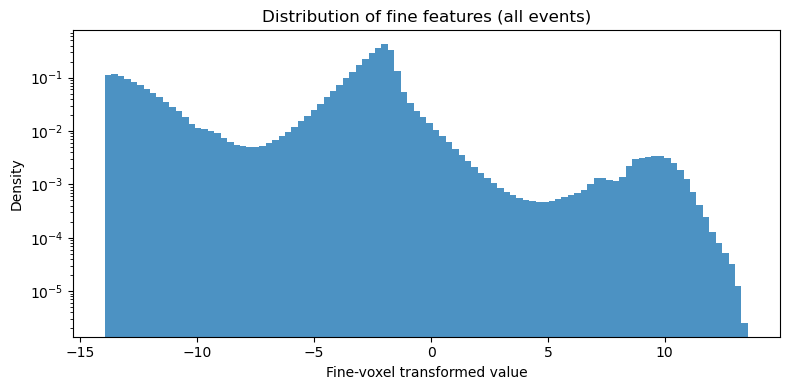

In [13]:
def histogram_fine_features(h5_path, fine_dim=12, nbins=120, chunk=1_000_000):
    import h5py, numpy as np, matplotlib.pyplot as plt

    # ---------- first pass: global min & max -------------------------------
    with h5py.File(h5_path, "r") as f:
        fine = f["fine_trans"]
        M    = fine.shape[0]

        gmin, gmax = np.inf, -np.inf
        for i in range(0, M, chunk):
            sl = fine[i:i+chunk, :fine_dim]
            gmin = min(gmin, sl.min())
            gmax = max(gmax, sl.max())

    # fixed bin edges for the whole file
    bin_edges = np.linspace(gmin, gmax, nbins + 1, dtype=np.float32)
    hist = np.zeros(nbins, dtype=np.float64)

    # ---------- second pass: accumulate counts -----------------------------
    with h5py.File(h5_path, "r") as f:
        fine = f["fine_trans"]
        for i in range(0, M, chunk):
            sl = fine[i:i+chunk, :fine_dim].ravel()
            h, _ = np.histogram(sl, bins=bin_edges)
            hist += h

    # density
    bin_width = bin_edges[1] - bin_edges[0]
    hist = hist / hist.sum() / bin_width

    # ---------- plot -------------------------------------------------------
    plt.figure(figsize=(8, 4))
    plt.bar(bin_edges[:-1], hist, width=bin_width, alpha=0.8)
    plt.yscale("log")
    plt.xlabel("Fine-voxel transformed value")
    plt.ylabel("Density")
    plt.title("Distribution of fine features (all events)")
    plt.tight_layout(); plt.show()

if MODE == 'A':
    histogram_fine_features('/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5', fine_dim=10, nbins=100)
else: 
    histogram_fine_features('/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5', fine_dim=12, nbins=120)

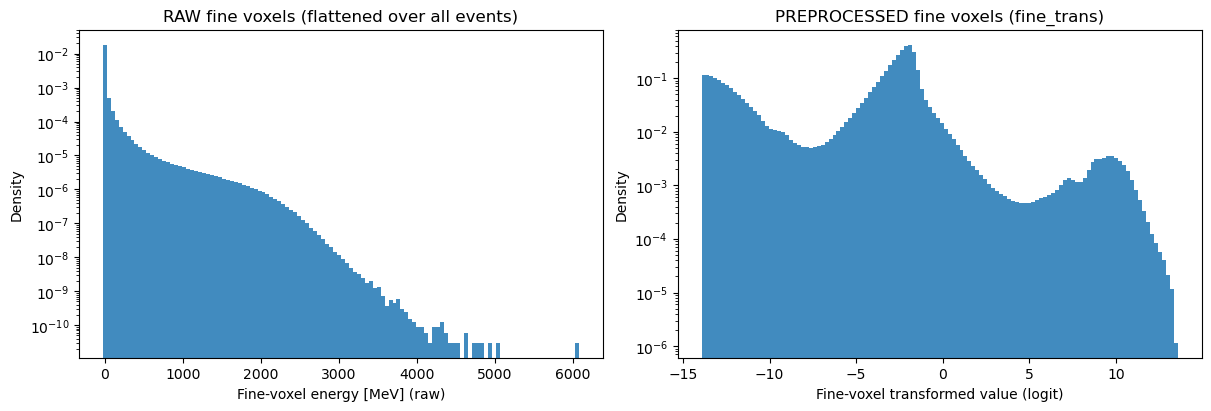

In [14]:
def plot_raw_vs_preprocessed_fine(cache_h5_path,
                                  nbins_raw=200,
                                  nbins_proc=120,
                                  target_raw_elems_per_chunk=10_000_000,   # ~10M raw floats per read
                                  trans_rows_per_chunk=2_000_000):         # rows of fine_trans per read
    """
    Side-by-side histograms:
      Left  = RAW fine-voxel energies from 'showers_raw' (no transform)
      Right = PREPROCESSED values from 'fine_trans'     (your logit space)

    Assumes cache contains:
      - 'showers_raw'  [N, 45, 16, 9]    (float32/float64)
      - 'fine_trans'   [M, Df]           (float32/float64)

    Binning:
      - RAW:   global [min, max] from 'showers_raw'
      - PROC:  global [min, max] from 'fine_trans'
    """
    import h5py, numpy as np, matplotlib.pyplot as plt

    with h5py.File(cache_h5_path, "r") as f:
        raw_ds  = f["showers_raw"]   # [N,45,16,9]
        proc_ds = f["fine_trans"]    # [M,Df]

        # ------------------ shapes & chunk sizes ------------------
        N, Z, A, R = raw_ds.shape
        elems_per_event = Z * A * R                 # 45*16*9 = 6480
        # derive events per chunk to hit ~target_raw_elems_per_chunk elements
        ev_per_chunk = max(1, int(target_raw_elems_per_chunk // elems_per_event))

        M, Df = proc_ds.shape
        # proc chunk is in rows (each has Df elements)

        # ------------------ FIRST PASS: min/max -------------------
        raw_min, raw_max = np.inf, -np.inf
        for e0 in range(0, N, ev_per_chunk):
            e1 = min(e0 + ev_per_chunk, N)
            arr = np.asarray(raw_ds[e0:e1, :, :, :])        # [ev,45,16,9]
            vmin = float(arr.min()); vmax = float(arr.max())
            if vmin < raw_min: raw_min = vmin
            if vmax > raw_max: raw_max = vmax

        proc_min, proc_max = np.inf, -np.inf
        for r0 in range(0, M, trans_rows_per_chunk):
            r1 = min(r0 + trans_rows_per_chunk, M)
            arr = np.asarray(proc_ds[r0:r1, :])            # [rows,Df]
            vmin = float(arr.min()); vmax = float(arr.max())
            if vmin < proc_min: proc_min = vmin
            if vmax > proc_max: proc_max = vmax

        # safety in case of degenerate ranges
        if not np.isfinite(raw_min): raw_min = 0.0
        if not np.isfinite(raw_max): raw_max = 1.0
        if raw_max == raw_min: raw_max = raw_min + 1.0

        if not np.isfinite(proc_min): proc_min = -1.0
        if not np.isfinite(proc_max): proc_max =  1.0
        if proc_max == proc_min: proc_max = proc_min + 1.0

        # ------------------ bins & accumulators -------------------
        raw_edges  = np.linspace(raw_min,  raw_max,  nbins_raw + 1,  dtype=np.float64)
        proc_edges = np.linspace(proc_min, proc_max, nbins_proc + 1, dtype=np.float64)
        hist_raw   = np.zeros(nbins_raw,  dtype=np.float64)
        hist_proc  = np.zeros(nbins_proc, dtype=np.float64)

        # ------------------ SECOND PASS: histograms ---------------
        # RAW
        for e0 in range(0, N, ev_per_chunk):
            e1 = min(e0 + ev_per_chunk, N)
            arr = np.asarray(raw_ds[e0:e1, :, :, :], dtype=np.float64).ravel()
            h, _ = np.histogram(arr, bins=raw_edges)
            hist_raw += h

        # PREPROCESSED
        for r0 in range(0, M, trans_rows_per_chunk):
            r1 = min(r0 + trans_rows_per_chunk, M)
            arr = np.asarray(proc_ds[r0:r1, :], dtype=np.float64).ravel()
            h, _ = np.histogram(arr, bins=proc_edges)
            hist_proc += h

        # densities
        bw_raw  = raw_edges[1]  - raw_edges[0]
        bw_proc = proc_edges[1] - proc_edges[0]
        if hist_raw.sum() > 0:
            hist_raw  = hist_raw  / hist_raw.sum()  / bw_raw
        if hist_proc.sum() > 0:
            hist_proc = hist_proc / hist_proc.sum() / bw_proc

    # ------------------ PLOT ------------------
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    # Left: RAW energies (no transform)
    ax[0].bar(raw_edges[:-1], hist_raw, width=bw_raw, alpha=0.85)
    ax[0].set_yscale("log")  # keep log-y so tails/zeros are visible; remove if you prefer linear
    ax[0].set_xlabel("Fine-voxel energy [MeV] (raw)")
    ax[0].set_ylabel("Density")
    ax[0].set_title(f"RAW fine voxels (flattened over all events)")

    # Right: PREPROCESSED (logit space)
    ax[1].bar(proc_edges[:-1], hist_proc, width=bw_proc, alpha=0.85)
    ax[1].set_yscale("log")
    ax[1].set_xlabel("Fine-voxel transformed value (logit)")
    ax[1].set_ylabel("Density")
    ax[1].set_title(f"PREPROCESSED fine voxels (fine_trans)")

    plt.show()


plot_raw_vs_preprocessed_fine("/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5", nbins_raw=120, nbins_proc=120)

In [15]:
def plot_fine_raw_vs_preproc_overlay_fast(cache_h5_path,
                                          nbins=150,
                                          raw_ev_chunk=2048,
                                          trans_rows_chunk=2_000_000,
                                          mode="prob_per_bin",   # "prob_per_bin" | "density" | "counts"
                                          shared_y=True,          # for "counts", shared_y=True is typical
                                          top_scale=1.0,          # scale factor applied to TOP (preproc) series in "counts" mode
                                          color_raw="royalblue",
                                          color_proc="orangered",
                                          alpha_fill=0.25,
                                          use_logy=True,
                                          lw=2.0,
                                          dpi=400):
    """
    Overlaid histograms with two x-axes (shared y optional):
      - Bottom axis: RAW fine-voxel energies ('showers_raw')
      - Top axis:    PREPROCESSED values ('fine_trans', logit space)

    mode:
      - "prob_per_bin": normalize each histogram so sum of bin heights = 1 (fraction per bin).
      - "density":      PDF normalization (area = 1).
      - "counts":       Raw bin counts (no normalization).

    shared_y:
      - If True, both plotted against the left y (good for shape comparison).
      - If False and mode="density", left y shows p_X(x), right y shows p_Z(z).
    """
    import h5py, numpy as np, matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # ---------- helpers ----------
    def streaming_min_max(ds, chunk, is_raw):
        N = ds.shape[0]
        gmin, gmax = None, None
        for i0 in range(0, N, chunk):
            i1 = min(i0 + chunk, N)
            arr = np.asarray(ds[i0:i1, :, :, :]) if is_raw else np.asarray(ds[i0:i1, :])
            mn, mx = np.nanmin(arr), np.nanmax(arr)
            gmin = mn if gmin is None else min(gmin, mn)
            gmax = mx if gmax is None else max(gmax, mx)
        if gmin == gmax:
            gmax = gmin + 1.0
        return float(gmin), float(gmax)

    # ---------- load + edges ----------
    with h5py.File(cache_h5_path, "r") as f:
        raw_ds, proc_ds = f["showers_raw"], f["fine_trans"]
        N, M = raw_ds.shape[0], proc_ds.shape[0]
        if N == 0 or M == 0:
            raise RuntimeError("Empty dataset detected.")

        raw_min, raw_max   = streaming_min_max(raw_ds,  raw_ev_chunk, True)
        proc_min, proc_max = streaming_min_max(proc_ds, trans_rows_chunk, False)

        raw_edges  = np.linspace(raw_min,  raw_max,  nbins + 1)
        proc_edges = np.linspace(proc_min, proc_max, nbins + 1)

        # ---------- stream histograms (counts) ----------
        counts_raw  = np.zeros(nbins, dtype=float)
        counts_proc = np.zeros(nbins, dtype=float)

        for e0 in range(0, N, raw_ev_chunk):
            e1 = min(e0 + raw_ev_chunk, N)
            arr = np.asarray(raw_ds[e0:e1, :, :, :])
            h, _ = np.histogram(arr.ravel(), bins=raw_edges)
            counts_raw += h

        for r0 in range(0, M, trans_rows_chunk):
            r1 = min(r0 + trans_rows_chunk, M)
            arr = np.asarray(proc_ds[r0:r1, :])
            h, _ = np.histogram(arr.ravel(), bins=proc_edges)
            counts_proc += h

    # ---------- normalization ----------
    if mode not in {"prob_per_bin", "density", "counts"}:
        raise ValueError("mode must be 'prob_per_bin', 'density', or 'counts'.")

    if mode == "prob_per_bin":
        # fraction per bin (sums to 1 across bins)
        y_raw  = counts_raw  / counts_raw.sum()  if counts_raw.sum()  > 0 else counts_raw
        y_proc = counts_proc / counts_proc.sum() if counts_proc.sum() > 0 else counts_proc
        y_label = "Probability per bin"
    elif mode == "density":
        # density (area = 1)
        bw_raw  = raw_edges[1]  - raw_edges[0]
        bw_proc = proc_edges[1] - proc_edges[0]
        y_raw  = (counts_raw  / counts_raw.sum()  / bw_raw)  if counts_raw.sum()  > 0 else counts_raw
        y_proc = (counts_proc / counts_proc.sum() / bw_proc) if counts_proc.sum() > 0 else counts_proc
        y_label = "Density"
    else:
        # COUNTS (no normalization). Optionally scale the TOP series to share the y range nicely.
        y_raw  = counts_raw
        y_proc = counts_proc * float(top_scale)
        y_label = "Counts"

    # ---------- set up figure ----------
    fig, ax = plt.subplots(figsize=(9.5, 5.2), constrained_layout=True, dpi=dpi)
    ax_top = ax.twiny()

    # Draw order: show top axis artists but keep them underneath by default
    ax_top.set_zorder(ax.get_zorder() - 1)
    ax.patch.set_visible(False)   # let top axis artists show through
    ax.set_axisbelow(True)
    ax_top.set_axisbelow(True)
    ax.grid(alpha=0.35)
    ax_top.grid(alpha=0.35)

    # Y scale (log for all; baseline must be positive)
    linthresh = 3e-9  # transition point (adjust to your preference)
    if use_logy:
        ax.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
        ax_top.set_yscale("symlog", linthresh=linthresh, linscale=1.0)

    # Helper to find positive finite values
    def finite_pos(a):
        a = a[np.isfinite(a)]
        return a[a > 0]

    valsL = finite_pos(y_raw)
    valsR = finite_pos(y_proc)
    ymaxL = float(valsL.max()) if valsL.size else 1.0
    ymaxR = float(valsR.max()) if valsR.size else 1.0
    yminL = float(valsL.min())/5 if valsL.size else 1e-6
    yminR = float(valsR.min())/5 if valsR.size else 1e-6
    baseline = max(min(yminL, yminR, 1e-12), 1e-12)

    # X padding
    raw_pad  = 0.02 * (raw_edges[-1]  - raw_edges[0])
    proc_pad = 0.02 * (proc_edges[-1] - proc_edges[0])
    ax.set_xlim(raw_edges[0]  - raw_pad,  raw_edges[-1]  + raw_pad)
    ax_top.set_xlim(proc_edges[0] - proc_pad, proc_edges[-1] + proc_pad)

    # ---------- draw with stairs ----------
    ax.stairs(y_raw,  raw_edges,  baseline=baseline, fill=True,
              color=color_raw,  alpha=alpha_fill, zorder=2)
    ax_top.stairs(y_proc, proc_edges, baseline=baseline, fill=True,
                  color=color_proc, alpha=alpha_fill, zorder=1)

    ax.stairs(y_raw,  raw_edges,  baseline=baseline, fill=False,
              color=color_raw,  linewidth=lw, zorder=5, label="Raw energies")
    ax_top.stairs(y_proc, proc_edges, baseline=baseline, fill=False,
                  color=color_proc, linewidth=lw, zorder=3, label="Preprocessed (logit)")

    # ---------- y-axis behavior ----------
    if mode == "density" and not shared_y:
        # Left y for raw density
        ax.set_ylim(baseline, ymaxL * 1.3)
        # Right y for preprocessed density (own scale)
        ax_right = ax.twinx()
        ax_right.set_yscale("log" if use_logy else "linear")
        ax_right.set_ylim(baseline, ymaxR * 1.3)
        ax_right.set_ylabel("Density (logit space)", fontsize=11)
        for spine in ["right"]:
            ax_right.spines[spine].set_alpha(0.6)
        y_label_left = "Density (raw energy)"
    else:
        ymax = max(ymaxL, ymaxR)
        ax.set_ylim(baseline, ymax * 1.3)
        ax_top.set_ylim(ax.get_ylim())
        y_label_left = y_label

    # ---------- labels, title, legend ----------
    ax.set_xlabel("Raw fine-voxel energy", fontsize=11)
    ax_top.set_xlabel("Preprocessed value (logit space)", fontsize=11)
    ax.set_ylabel(y_label_left, fontsize=11)
    ax.set_title("Raw vs Preprocessed fine-voxel distribution", fontsize=13)

    label_proc = "Preprocessed (logit)"
    if mode == "counts" and top_scale != 1.0:
        label_proc += f" × {top_scale:g}"

    handles = [
        Line2D([0], [0], color=color_raw,  lw=lw, label="Raw energies"),
        Line2D([0], [0], color=color_proc, lw=lw, label=label_proc),
    ]
    ax.legend(handles=handles, frameon=False, loc="best")

    plt.show()

#plot_fine_raw_vs_preproc_overlay_fast(
#    "/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5",
#    nbins=150, mode="prob_per_bin", shared_y=True, top_scale=0.01, dpi=400
#)


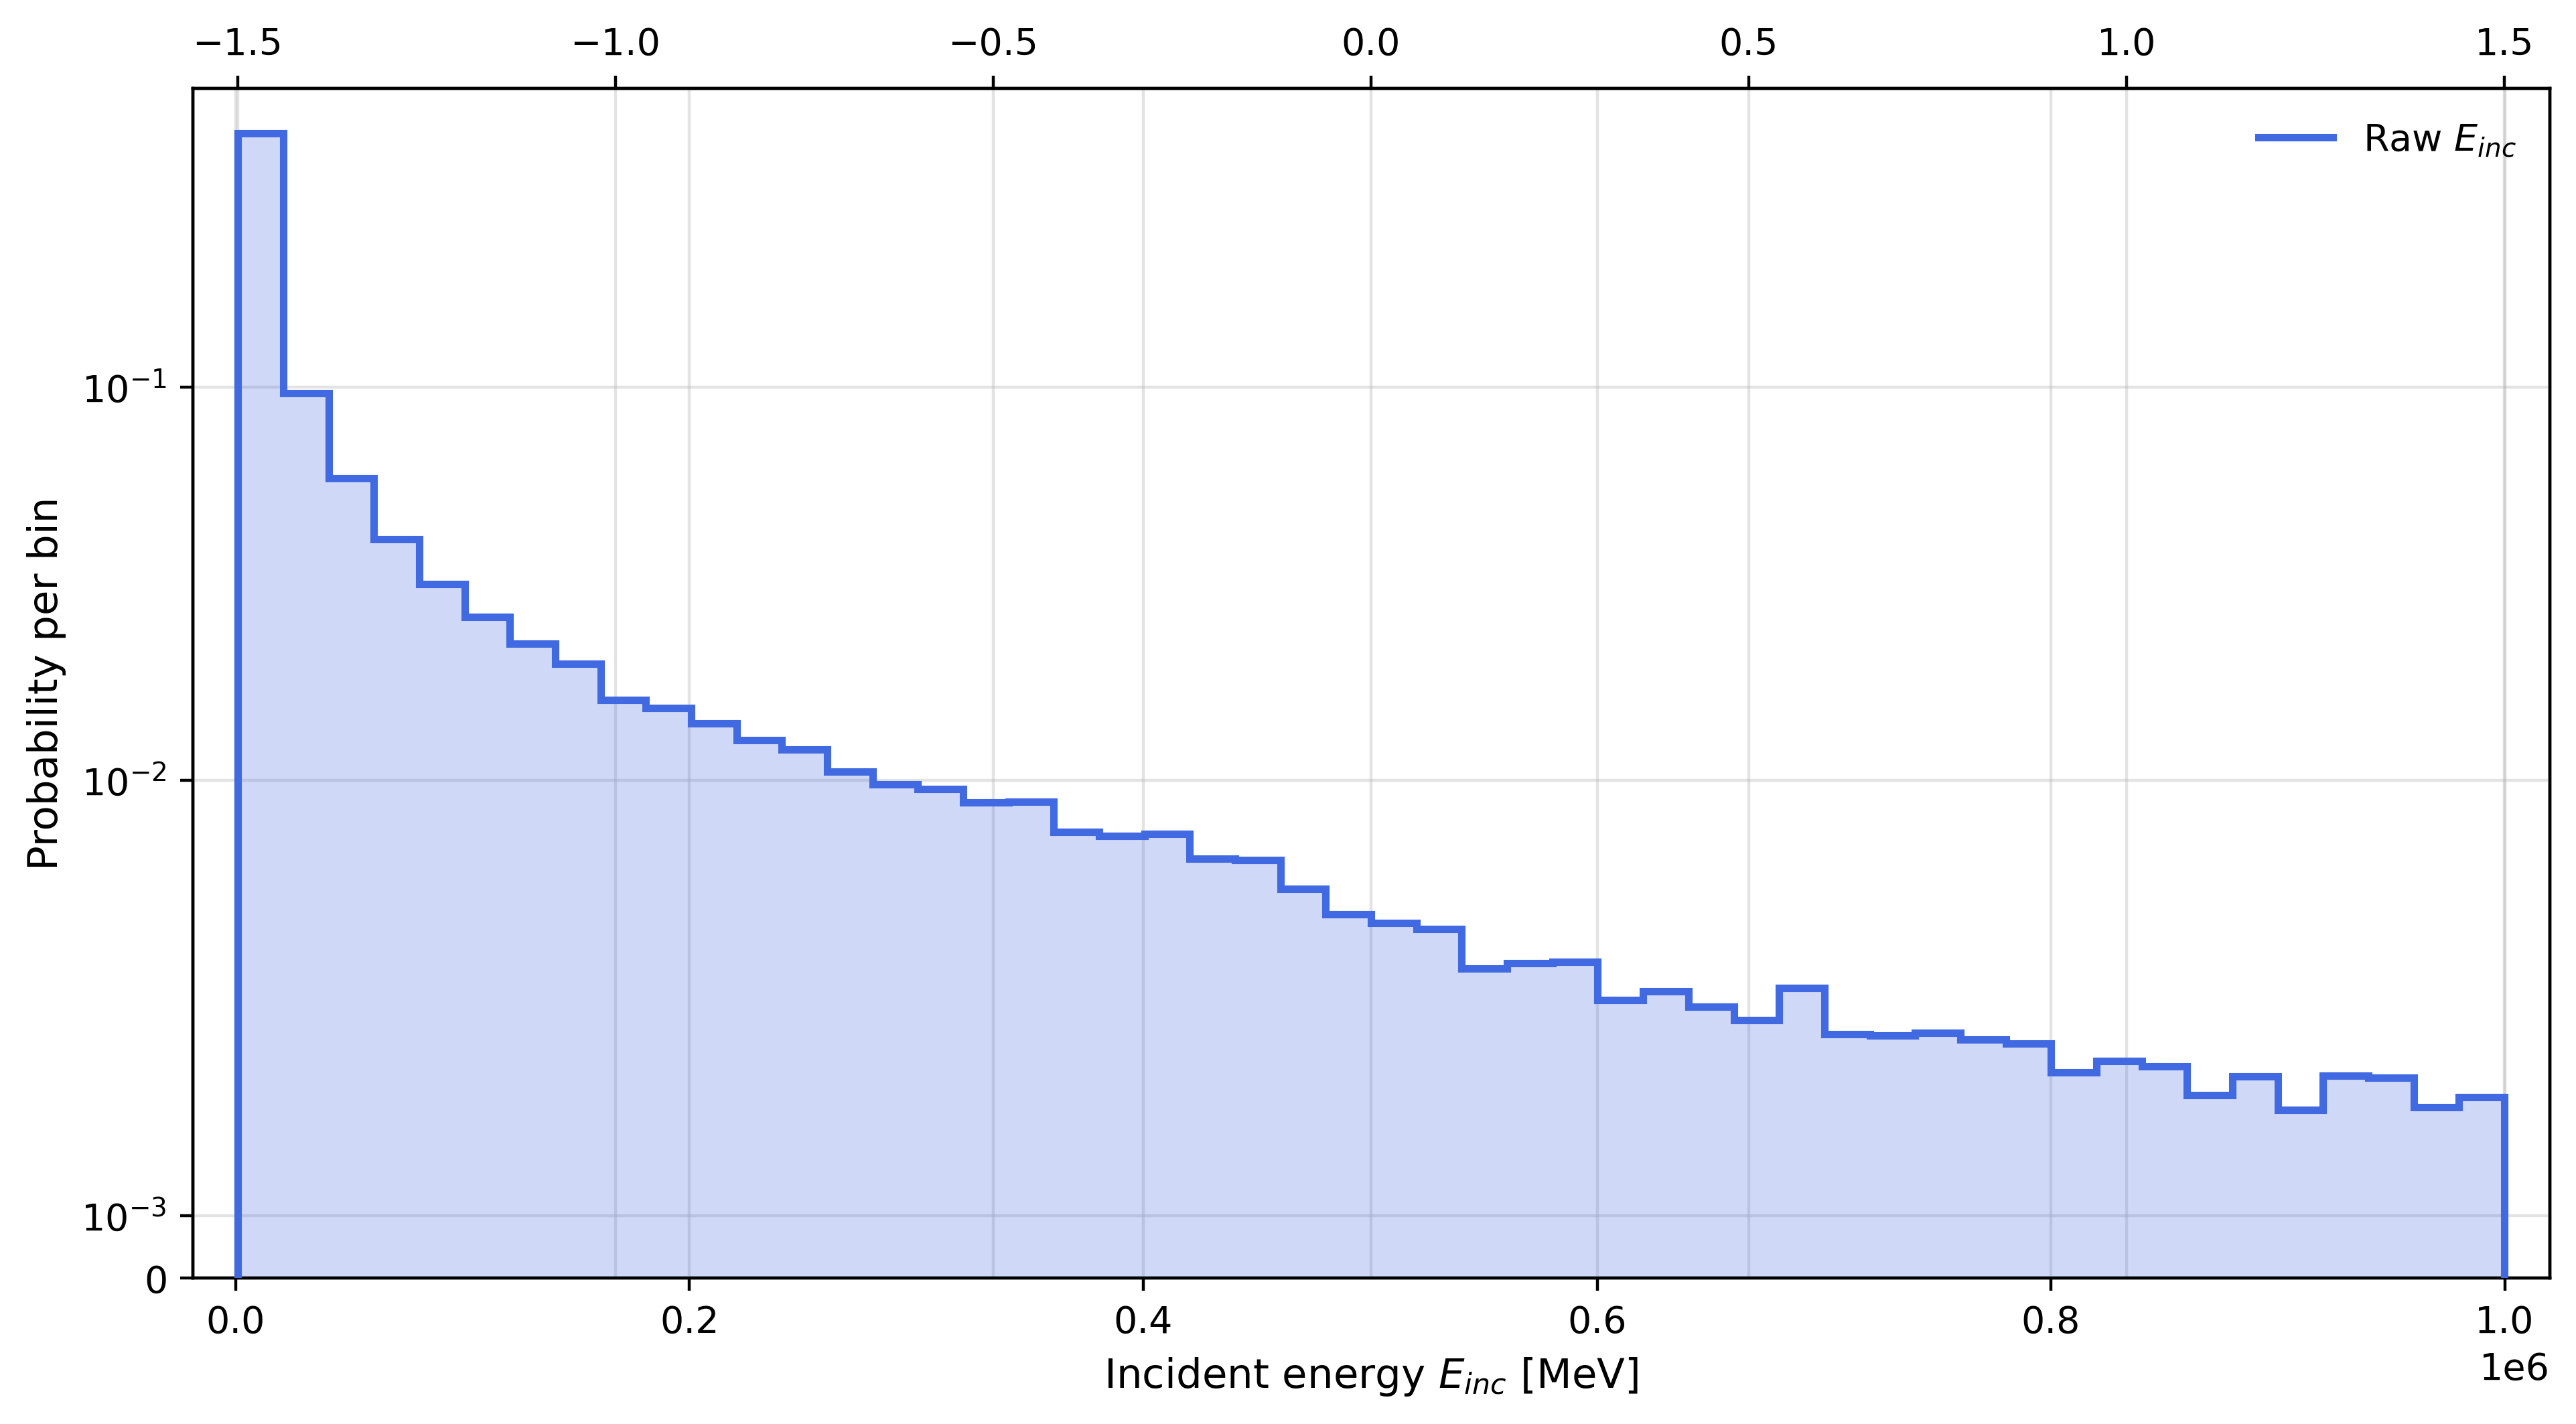

IOStream.flush timed out


In [16]:
def plot_Einc_raw_vs_preproc_overlay_fast(cache_h5_path,
                                          nbins=150,
                                          rows_chunk=2_000_000,
                                          mode="prob_per_bin",   # "prob_per_bin" | "density" | "counts"
                                          shared_y=True,
                                          top_scale=1.0,          # scale factor applied to TOP (preproc) series in "counts" mode
                                          color_raw="royalblue",
                                          color_proc="orangered",
                                          alpha_fill=0.25,
                                          use_logy=True,
                                          lw=2.0,
                                          dpi=400):
    """
    Overlaid histograms with two x-axes (shared y optional):
      - Bottom axis: RAW incident energy (MeV)  -> dataset 'incident_energies' (shape [N,1])
      - Top axis:    PREPROCESSED incident energy -> cond_trans[:, 0] = log10(E_inc / 10^4.5 MeV)

    mode:
      - "prob_per_bin": normalize each histogram so sum of bin heights = 1 (fraction per bin).
      - "density":      PDF normalization (area = 1).
      - "counts":       Raw bin counts (no normalization).

    shared_y:
      - If True, both plotted against the left y (good for shape comparison).
      - If False and mode="density", left y shows p_raw, right y shows p_preproc.
    """
    import h5py, numpy as np, matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # ---------- helpers ----------
    def streaming_min_max_vector(ds, chunk, col=None):
        """Min/max over a 1D array-like stored in HDF5; if 'col' is given, read that column from a 2D dataset."""
        N = ds.shape[0]
        gmin, gmax = None, None
        for i0 in range(0, N, chunk):
            i1 = min(i0 + chunk, N)
            if col is None:
                arr = np.asarray(ds[i0:i1]).ravel()
            else:
                arr = np.asarray(ds[i0:i1, col]).ravel()
            mn, mx = np.nanmin(arr), np.nanmax(arr)
            gmin = mn if gmin is None else min(gmin, mn)
            gmax = mx if gmax is None else max(gmax, mx)
        if gmin == gmax:
            gmax = gmin + 1.0
        return float(gmin), float(gmax)

    # ---------- load + edges ----------
    with h5py.File(cache_h5_path, "r") as f:
        inc_ds   = f["incident_energies"]   # [N, 1] raw MeV
        cond_ds  = f["cond_trans"]          # [M, Dcond], preprocessed; column 0 is preproc E_inc

        N = inc_ds.shape[0]
        M = cond_ds.shape[0]
        if N == 0 or M == 0:
            raise RuntimeError("Empty dataset detected.")

        # ranges
        raw_min,  raw_max  = streaming_min_max_vector(inc_ds,  rows_chunk, col=0)
        proc_min, proc_max = streaming_min_max_vector(cond_ds, rows_chunk, col=0)

        raw_edges  = np.linspace(raw_min,  raw_max,  nbins + 1)
        proc_edges = np.linspace(proc_min, proc_max, nbins + 1)

        # ---------- stream histograms (counts) ----------
        counts_raw  = np.zeros(nbins, dtype=float)
        counts_proc = np.zeros(nbins, dtype=float)

        # raw incident energies
        for i0 in range(0, N, rows_chunk):
            i1 = min(i0 + rows_chunk, N)
            arr = np.asarray(inc_ds[i0:i1, 0]).ravel()
            h, _ = np.histogram(arr, bins=raw_edges)
            counts_raw += h

        # preprocessed incident energies (first column of cond_trans)
        for r0 in range(0, M, rows_chunk):
            r1 = min(r0 + rows_chunk, M)
            arr = np.asarray(cond_ds[r0:r1, 0]).ravel()
            h, _ = np.histogram(arr, bins=proc_edges)
            counts_proc += h

    # ---------- normalization ----------
    if mode not in {"prob_per_bin", "density", "counts"}:
        raise ValueError("mode must be 'prob_per_bin', 'density', or 'counts'.")

    if mode == "prob_per_bin":
        y_raw  = counts_raw  / counts_raw.sum()  if counts_raw.sum()  > 0 else counts_raw
        y_proc = counts_proc / counts_proc.sum() if counts_proc.sum() > 0 else counts_proc
        y_label = "Probability per bin"
    elif mode == "density":
        bw_raw  = raw_edges[1]  - raw_edges[0]
        bw_proc = proc_edges[1] - proc_edges[0]
        y_raw  = (counts_raw  / counts_raw.sum()  / bw_raw)  if counts_raw.sum()  > 0 else counts_raw
        y_proc = (counts_proc / counts_proc.sum() / bw_proc) if counts_proc.sum() > 0 else counts_proc
        y_label = "Density"
    else:
        y_raw  = counts_raw
        y_proc = counts_proc * float(top_scale)
        y_label = "Counts"

    # ---------- set up figure ----------
    fig, ax = plt.subplots(figsize=(9.5, 5.2), constrained_layout=True, dpi=dpi)
    ax_top = ax.twiny()

    ax_top.set_zorder(ax.get_zorder() - 1)
    ax.patch.set_visible(False)
    ax.set_axisbelow(True)
    ax_top.set_axisbelow(True)
    ax.grid(alpha=0.35)
    ax_top.grid(alpha=0.35)

    # Y scale
    linthresh = 7e-3
    if use_logy:
        ax.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
        ax_top.set_yscale("symlog", linthresh=linthresh, linscale=1.0)

    def finite_pos(a):
        a = a[np.isfinite(a)]
        return a[a > 0]

    valsL = finite_pos(y_raw)
    valsR = finite_pos(y_proc)
    ymaxL = float(valsL.max()) if valsL.size else 1.0
    ymaxR = float(valsR.max()) if valsR.size else 1.0
    yminL = float(valsL.min())/5 if valsL.size else 1e-6
    yminR = float(valsR.min())/5 if valsR.size else 1e-6
    baseline = max(min(yminL, yminR, 1e-12), 1e-12)

    # X padding
    raw_pad  = 0.02 * (raw_edges[-1]  - raw_edges[0])
    proc_pad = 0.02 * (proc_edges[-1] - proc_edges[0])
    ax.set_xlim(raw_edges[0]  - raw_pad,  raw_edges[-1]  + raw_pad)
    ax_top.set_xlim(proc_edges[0] - proc_pad, proc_edges[-1] + proc_pad)

    # ---------- draw with stairs ----------
    ax.stairs(y_raw,  raw_edges,  baseline=baseline, fill=True,
              color=color_raw,  alpha=alpha_fill, zorder=2)
    #ax_top.stairs(y_proc, proc_edges, baseline=baseline, fill=True,
    #              color=color_proc, alpha=alpha_fill, zorder=1)

    ax.stairs(y_raw,  raw_edges,  baseline=baseline, fill=False,
              color=color_raw,  linewidth=lw, zorder=5, label="Raw $E_{inc}$ (MeV)")
    #ax_top.stairs(y_proc, proc_edges, baseline=baseline, fill=False,
    #              color=color_proc, linewidth=lw, zorder=3, label="Preprocessed: $\\log_{10}(E_{inc}/10^{4.5}\\,\\mathrm{MeV})$")

    # ---------- y-axis behavior ----------
    if mode == "density" and not shared_y:
        ax.set_ylim(baseline, ymaxL * 1.3)
        ax_right = ax.twinx()
        ax_right.set_yscale("log" if use_logy else "linear")
        ax_right.set_ylim(baseline, ymaxR * 1.3)
        ax_right.set_ylabel("Density (preprocessed)", fontsize=11)
        for spine in ["right"]:
            ax_right.spines[spine].set_alpha(0.6)
        y_label_left = "Density (raw)"
    else:
        ymax = max(ymaxL, ymaxR)
        ax.set_ylim(baseline, ymax * 1.3)
        ax_top.set_ylim(ax.get_ylim())
        y_label_left = y_label

    # ---------- labels, title, legend ----------
    ax.set_xlabel("Incident energy $E_{inc}$ [MeV]", fontsize=11)
    #ax_top.set_xlabel("Preprocessed $\\log_{10}(E_{inc}/10^{4.5}\\,\\mathrm{MeV})$", fontsize=11)
    ax.set_ylabel(y_label_left, fontsize=11)
    #ax.set_title("Incident energy: Raw vs Preprocessed", fontsize=13)

    label_proc = "Preprocessed $\\log_{10}(E_{inc}/10^{4.5})$"
    if mode == "counts" and top_scale != 1.0:
        label_proc += f" × {top_scale:g}"

    handles = [
        Line2D([0], [0], color=color_raw,  lw=lw, label="Raw $E_{inc}$"),
        #Line2D([0], [0], color=color_proc, lw=lw, label=label_proc),
    ]
    ax.legend(handles=handles, frameon=False, loc="best")

    plt.show()





plot_Einc_raw_vs_preproc_overlay_fast(
    "/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5",
    nbins=50, mode="prob_per_bin", shared_y=True, top_scale=1.0, dpi=400
)


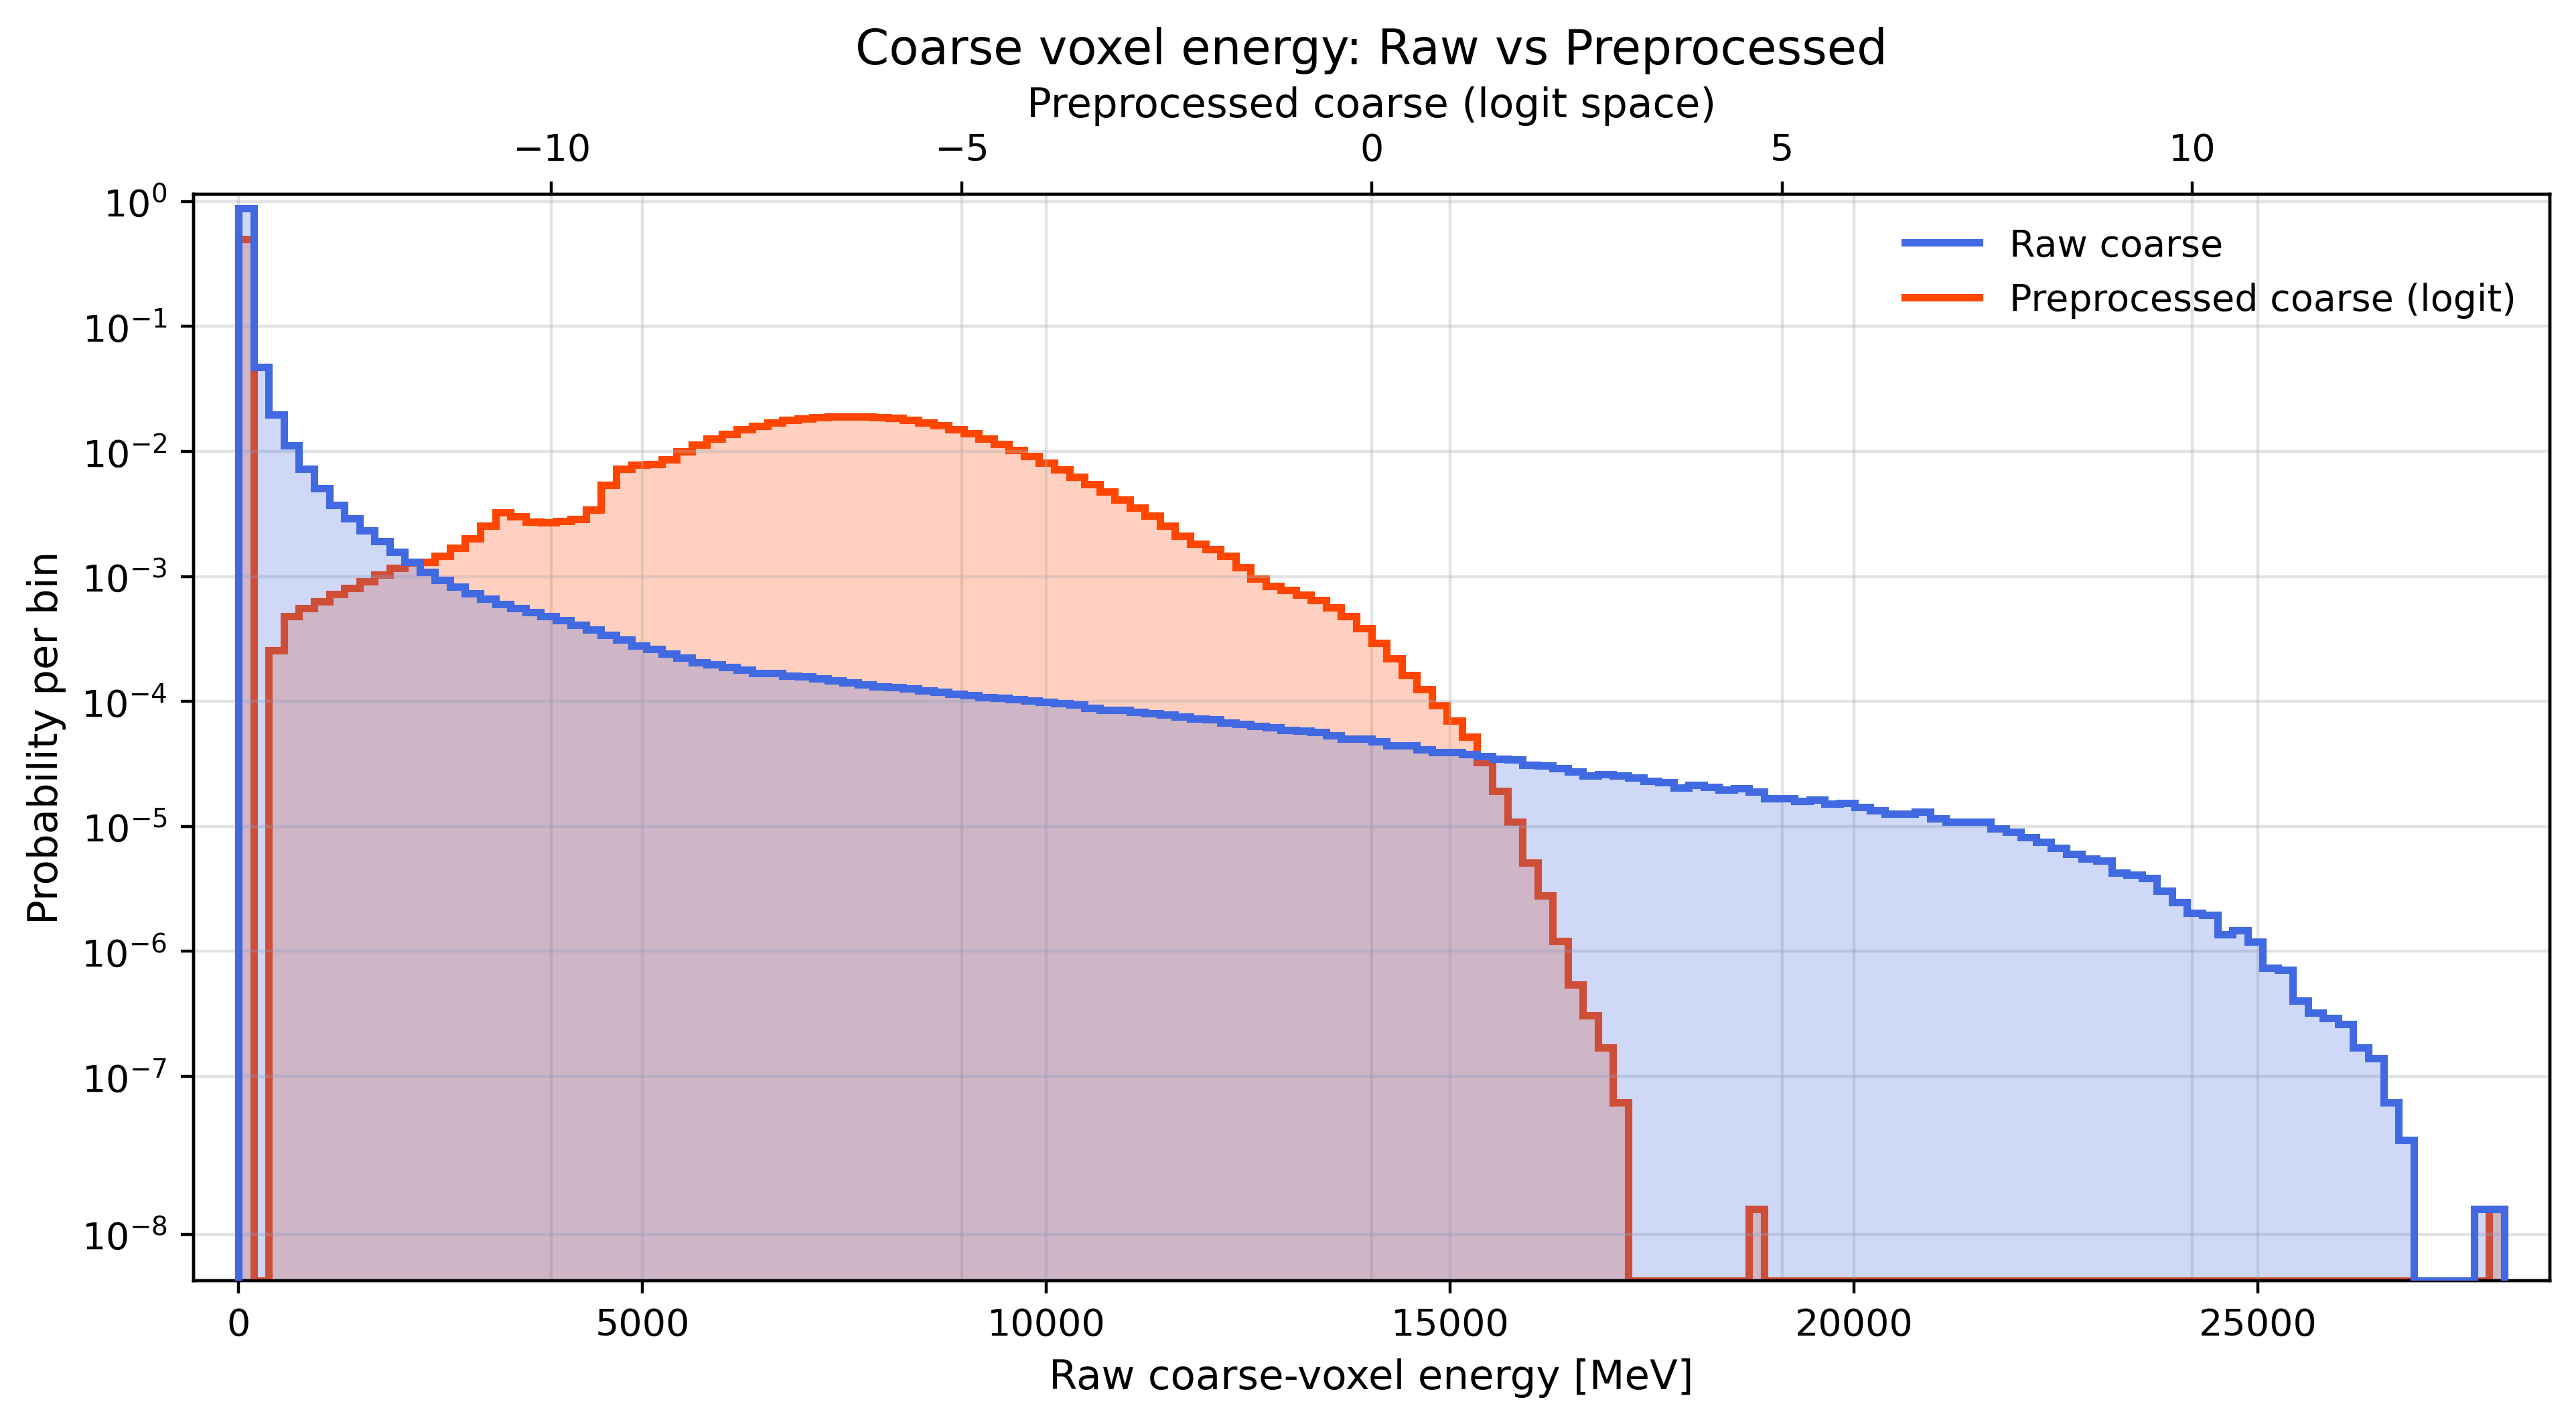

In [17]:
def plot_coarse_raw_vs_preproc_overlay_fast(cache_h5_path,
                                            nbins=150,
                                            ev_chunk=2048,             # chunk over events for coarse_showers
                                            rows_chunk=2_000_000,      # chunk over rows for cond_trans
                                            mode="prob_per_bin",       # "prob_per_bin" | "density" | "counts"
                                            shared_y=True,
                                            top_scale=1.0,             # scale the TOP (preproc) series in "counts" mode
                                            coarse_col=1,              # column in cond_trans for coarse preproc value
                                            color_raw="royalblue",
                                            color_proc="orangered",
                                            alpha_fill=0.25,
                                            use_logy=True,
                                            lw=2.0,
                                            dpi=400):
    """
    Overlaid histograms with twin x-axes (shared y optional):
      - Bottom axis: RAW coarse-voxel energies (MeV) from 'coarse_showers' [N, nz, na, nr]
      - Top axis:    PREPROCESSED coarse value from 'cond_trans[:, coarse_col]' (logit space)

    Notes
    -----
    * cond_trans rows typically correspond to *coarse voxels* (incident energy is repeated);
      'coarse_col' is the column holding the per-row coarse voxel's preprocessed energy.
    * If your pipeline places coarse after E_inc, 'coarse_col=1' is correct.

    mode:
      - "prob_per_bin": bin heights sum to 1 (fraction per bin).
      - "density":      area under curve = 1.
      - "counts":       raw bin counts.

    shared_y:
      - If True, both are read on the left y-axis (good for shape comparison).
      - If False and mode="density", left y shows raw density, right y shows preproc density.
    """
    import h5py, numpy as np, matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # ---------- helpers ----------
    def streaming_min_max_coarse(ds, chunk_events):
        """Min/max over 4D coarse_showers by streaming events."""
        N = ds.shape[0]
        gmin, gmax = None, None
        for i0 in range(0, N, chunk_events):
            i1 = min(i0 + chunk_events, N)
            arr = np.asarray(ds[i0:i1, :, :, :])
            mn, mx = np.nanmin(arr), np.nanmax(arr)
            gmin = mn if gmin is None else min(gmin, mn)
            gmax = mx if gmax is None else max(gmax, mx)
        if gmin == gmax:
            gmax = gmin + 1.0
        return float(gmin), float(gmax)

    def streaming_min_max_col(ds, chunk_rows, col):
        """Min/max over a single column in a 2D dataset by streaming rows."""
        N = ds.shape[0]
        gmin, gmax = None, None
        for r0 in range(0, N, chunk_rows):
            r1 = min(r0 + chunk_rows, N)
            arr = np.asarray(ds[r0:r1, col]).ravel()
            mn, mx = np.nanmin(arr), np.nanmax(arr)
            gmin = mn if gmin is None else min(gmin, mn)
            gmax = mx if gmax is None else max(gmax, mx)
        if gmin == gmax:
            gmax = gmin + 1.0
        return float(gmin), float(gmax)

    # ---------- load + edges ----------
    with h5py.File(cache_h5_path, "r") as f:
        coarse_ds = f["coarse_showers"]   # [N, nz, na, nr] raw MeV
        cond_ds   = f["cond_trans"]       # [N_coarse, D_cond], column 'coarse_col' = preproc coarse

        N_ev = coarse_ds.shape[0]
        N_rows = cond_ds.shape[0]
        if N_ev == 0 or N_rows == 0:
            raise RuntimeError("Empty dataset detected (coarse_showers or cond_trans).")

        raw_min,  raw_max  = streaming_min_max_coarse(coarse_ds, ev_chunk)
        proc_min, proc_max = streaming_min_max_col(cond_ds, rows_chunk, coarse_col)

        raw_edges  = np.linspace(raw_min,  raw_max,  nbins + 1)
        proc_edges = np.linspace(proc_min, proc_max, nbins + 1)

        # ---------- stream histograms (counts) ----------
        counts_raw  = np.zeros(nbins, dtype=float)
        counts_proc = np.zeros(nbins, dtype=float)

        # raw coarse (flatten each chunk)
        for i0 in range(0, N_ev, ev_chunk):
            i1 = min(i0 + ev_chunk, N_ev)
            arr = np.asarray(coarse_ds[i0:i1, :, :, :]).ravel()
            h, _ = np.histogram(arr, bins=raw_edges)
            counts_raw += h

        # preprocessed coarse (single column)
        for r0 in range(0, N_rows, rows_chunk):
            r1 = min(r0 + rows_chunk, N_rows)
            arr = np.asarray(cond_ds[r0:r1, coarse_col]).ravel()
            h, _ = np.histogram(arr, bins=proc_edges)
            counts_proc += h

    # ---------- normalization ----------
    if mode not in {"prob_per_bin", "density", "counts"}:
        raise ValueError("mode must be 'prob_per_bin', 'density', or 'counts'.")

    if mode == "prob_per_bin":
        y_raw  = counts_raw  / counts_raw.sum()  if counts_raw.sum()  > 0 else counts_raw
        y_proc = counts_proc / counts_proc.sum() if counts_proc.sum() > 0 else counts_proc
        y_label = "Probability per bin"
    elif mode == "density":
        bw_raw  = raw_edges[1]  - raw_edges[0]
        bw_proc = proc_edges[1] - proc_edges[0]
        y_raw  = (counts_raw  / counts_raw.sum()  / bw_raw)  if counts_raw.sum()  > 0 else counts_raw
        y_proc = (counts_proc / counts_proc.sum() / bw_proc) if counts_proc.sum() > 0 else counts_proc
        y_label = "Density"
    else:
        y_raw  = counts_raw
        y_proc = counts_proc * float(top_scale)
        y_label = "Counts"

    # ---------- figure ----------
    fig, ax = plt.subplots(figsize=(9.5, 5.2), constrained_layout=True, dpi=dpi)
    ax_top = ax.twiny()

    ax_top.set_zorder(ax.get_zorder() - 1)
    ax.patch.set_visible(False)
    ax.set_axisbelow(True)
    ax_top.set_axisbelow(True)
    ax.grid(alpha=0.35)
    ax_top.grid(alpha=0.35)

    # Y scale
    linthresh = 3e-8
    if use_logy:
        ax.set_yscale("symlog", linthresh=linthresh, linscale=1.0)
        ax_top.set_yscale("symlog", linthresh=linthresh, linscale=1.0)

    def finite_pos(a):
        a = a[np.isfinite(a)]
        return a[a > 0]

    valsL = finite_pos(y_raw)
    valsR = finite_pos(y_proc)
    ymaxL = float(valsL.max()) if valsL.size else 1.0
    ymaxR = float(valsR.max()) if valsR.size else 1.0
    yminL = float(valsL.min())/5 if valsL.size else 1e-6
    yminR = float(valsR.min())/5 if valsR.size else 1e-6
    baseline = max(min(yminL, yminR, 1e-12), 1e-12)

    # X padding
    raw_pad  = 0.02 * (raw_edges[-1]  - raw_edges[0])
    proc_pad = 0.02 * (proc_edges[-1] - proc_edges[0])
    ax.set_xlim(raw_edges[0]  - raw_pad,  raw_edges[-1]  + raw_pad)
    ax_top.set_xlim(proc_edges[0] - proc_pad, proc_edges[-1] + proc_pad)

    # ---------- draw ----------
    ax.stairs(y_raw,  raw_edges,  baseline=baseline, fill=True,
              color=color_raw,  alpha=alpha_fill, zorder=2)
    ax_top.stairs(y_proc, proc_edges, baseline=baseline, fill=True,
                  color=color_proc, alpha=alpha_fill, zorder=1)

    ax.stairs(y_raw,  raw_edges,  baseline=baseline, fill=False,
              color=color_raw,  linewidth=lw, zorder=5, label="Raw coarse energy (MeV)")
    ax_top.stairs(y_proc, proc_edges, baseline=baseline, fill=False,
                  color=color_proc, linewidth=lw, zorder=3,
                  label="Preprocessed coarse (logit)")

    # ---------- y-axis behavior ----------
    if mode == "density" and not shared_y:
        ax.set_ylim(baseline, ymaxL * 1.3)
        ax_right = ax.twinx()
        ax_right.set_yscale("log" if use_logy else "linear")
        ax_right.set_ylim(baseline, ymaxR * 1.3)
        ax_right.set_ylabel("Density (preprocessed)", fontsize=11)
        for spine in ["right"]:
            ax_right.spines[spine].set_alpha(0.6)
        y_label_left = "Density (raw)"
    else:
        ymax = max(ymaxL, ymaxR)
        ax.set_ylim(baseline, ymax * 1.3)
        ax_top.set_ylim(ax.get_ylim())
        y_label_left = y_label

    # ---------- labels, title, legend ----------
    ax.set_xlabel("Raw coarse-voxel energy [MeV]", fontsize=11)
    ax_top.set_xlabel("Preprocessed coarse (logit space)", fontsize=11)
    ax.set_ylabel(y_label_left, fontsize=11)
    ax.set_title("Coarse voxel energy: Raw vs Preprocessed", fontsize=13)

    label_proc = "Preprocessed coarse (logit)"
    if mode == "counts" and top_scale != 1.0:
        label_proc += f" × {top_scale:g}"

    handles = [
        Line2D([0], [0], color=color_raw,  lw=lw, label="Raw coarse"),
        Line2D([0], [0], color=color_proc, lw=lw, label=label_proc),
    ]
    ax.legend(handles=handles, frameon=False, loc="best")

    plt.show()




#plot_coarse_raw_vs_preproc_overlay_fast(
#    "/teo_fs_fast/users/acosso/Dataset/full_preproc_A.hdf5",
#    nbins=150, mode="prob_per_bin", shared_y=True, top_scale=1.0, coarse_col=1, dpi=400
#)


In [18]:
def plot_corner_fine_layers(cache_h5_path,
                            max_points=200_000,
                            bins=40,
                            smooth2d=1,
                            color="#1f77b4",
                            seed=1234,
                            *,
                            all: bool = True,
                            layer_range: tuple[int, int] | None = None,
                            show: bool = True,
                            return_fig: bool = False):
    """
    Corner plot where each dimension is one *global fine-z layer*.

    If `all=True`  -> use all 45 layers (0..44).
    If `all=False` -> you MUST pass `layer_range=(first,last)` with 0 <= first <= last < 45.

    Tips to avoid double plots in notebooks:
      - Use `show=True, return_fig=False` (default), or
      - Use `show=False, return_fig=True` and then explicitly `display(fig)` yourself.

    Geometry auto-inferred from cache:
      fine_z = 45, fine_alpha = 16, fine_r = 9.

    Returns:
      Figure if `return_fig=True`, else None.
    """
    import h5py, numpy as np, matplotlib.pyplot as plt
    try:
        from GMetrics.corner import corner as corner_plot
    except ImportError:
        from corner import corner as corner_plot

    rng = np.random.default_rng(seed)

    # ---- read shapes and infer geometry ----
    with h5py.File(cache_h5_path, "r") as f:
        cs_shape  = f["coarse_showers"].shape    # [N, nz, na, nr]
        ft_shape  = f["fine_trans"].shape        # [M, Df]

        N, nz, na, nr = cs_shape
        M, Df = ft_shape
        rows_per_event = nz * na * nr
        assert M == N * rows_per_event, "fine_trans first dim mismatch with N*nz*na*nr"

        # fine granularity (fixed by detector); coarse splits inferred
        FZ, FA, FR = 45, 16, 9
        zf = FZ // nz
        af = FA // na
        rf = FR // nr
        assert zf * nz == FZ and af * na == FA and rf * nr == FR, "Inconsistent geometry inference."
        assert Df == zf * af * rf, "fine_trans second dim must equal zf*af*rf."

        AR = na * nr           # rows per coarse layer per event
        S  = af * rf           # subfine choices per fine-z (contiguous columns)
        total_tuples = N * AR * S

        K = min(max_points, total_tuples)
        idx_e  = rng.integers(0, N,  size=K, endpoint=False)      # events
        idx_ar = rng.integers(0, AR, size=K, endpoint=False)      # (a,r) packed
        idx_s  = rng.integers(0, S,  size=K, endpoint=False)      # subfine inside (alpha, r)

        idx_a = idx_ar // nr
        idx_r = idx_ar %  nr

    # ---- choose which global layers to include ----
    if all:
        selected_layers = list(range(FZ))
    else:
        if layer_range is None or len(layer_range) != 2:
            raise ValueError("When all=False, provide layer_range=(first_layer, last_layer).")
        L0, L1 = int(layer_range[0]), int(layer_range[1])
        if not (0 <= L0 <= L1 < FZ):
            raise ValueError(f"layer_range must satisfy 0 <= first <= last < {FZ}. Got {layer_range}.")
        selected_layers = list(range(L0, L1 + 1))

    D = len(selected_layers)   # output dimensionality

    # ---- allocate output ----
    X = np.empty((K, D), dtype=np.float32)

    # ---- group samples by event for efficient reading ----
    import collections
    by_event = collections.defaultdict(list)
    for i in range(K):
        by_event[int(idx_e[i])].append(i)

    with h5py.File(cache_h5_path, "r") as f:
        fine_ds = f["fine_trans"]

        for e, sample_idxs in by_event.items():
            # cache [AR, Df] blocks per coarse layer for this event
            event_cache = {}

            def get_block(cl):
                if cl in event_cache:
                    return event_cache[cl]
                base = e * rows_per_event + cl * AR
                blk = fine_ds[base:base + AR, :]   # (AR, Df)
                event_cache[cl] = blk
                return blk

            for i in sample_idxs:
                a = int(idx_a[i]); r = int(idx_r[i]); s = int(idx_s[i])
                ar = a * nr + r

                # fill vector over selected global layers
                for j, L in enumerate(selected_layers):
                    cl = L // zf
                    zl = L %  zf
                    col = zl * S + s
                    blk = get_block(cl)            # (AR, Df)
                    X[i, j] = blk[ar, col]

    # ---- robust per-dimension ranges ----
    q_lo, q_hi = 0.001, 0.999
    ranges = []
    for j in range(D):
        v = X[:, j]
        v = v[np.isfinite(v)]
        if v.size == 0:
            ranges.append([-1.0, 1.0])
        else:
            lo, hi = np.quantile(v, [q_lo, q_hi])
            if lo == hi:
                hi = lo + 1.0
            ranges.append([float(lo), float(hi)])

    labels = [rf"fine layer {L}" for L in selected_layers]

    # ---- plot (control double-render) ----
    fig = corner_plot(
        X,                     # (nsamples, ndim)
        bins=bins,
        range=ranges,
        color=color,
        smooth=smooth2d,
        labels=labels,
        show_titles=False,
        plot_datapoints=False,
        plot_density=True,
        plot_contours=True,
        no_fill_contours=True,
        use_math_text=True,
        hist_kwargs={"linewidth": 1.0},
        contour_kwargs={"linewidths": 0.9},
    )

    if show:
        import matplotlib.pyplot as plt
        plt.show()

    if return_fig:
        return fig
    else:
        # avoid Jupyter auto-displaying the returned Figure → return None
        return None


# Bijector init

In [19]:

bijector_name = 'MsplineN'
spline_knots = 8
range_min = -14
eps_regulariser = 1e-4
regulariser = 'l2'
if MODE == 'A':
    ndims = 10 
    ncond = 31 if layer_energies else 26

else: 
    ndims = 12
    ncond = 57 if layer_energies else 56
n_hidden=[128, 128]
num_bijectors = 4
activation='relu'
kernel_constraint = None
#kernel_constraint = tf.keras.constraints.MaxNorm(5.0)
bias_initializer=tf.keras.initializers.Constant(0.01)
#bias_initializer = tf.keras.initializers.Zeros()
MAF = Bijectors.ChooseCondBijector(bijector_name, ndims, spline_knots, 
                            num_bijectors, range_min, n_hidden, activation, 
                            regulariser, eps_regulariser, conditional_event_shape=(ncond,),
                            input_structure = None, 
                            bias_initializer=bias_initializer, 
                            kernel_constraint=kernel_constraint,
                            shuffle = 'RandomShuffle',
                            perm_style = 'reverse',
                            batch_norm=False,
                            conditional_input_layers='first_layer',
                            tails='linear')


[<tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_0' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_0' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_1' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp

# TODO

## Now working: 
- togliere il clipping dove non necessario 
- Preprocess il dataset completo 
- capire se allenare solo in mode = A o anche mode = B
- capire come fare il preprocess del dataset di evaluation 
- niente inverte il **preprocess dopo il sampling** in questo momento? 
- aggiustare le funzioni di plot deglishowers
- **AGGIUNGERE TUTTA LA PARTE DI METRICHE**

check in case it breaks
- float64 **DONE**
- togli conditionals
- batch norm
- clipping 
- histo pesi 
- togli lr_schedule 

In [20]:
base_dist = tfd.MultivariateNormalDiag(loc=tf.zeros(ndims, dtype=tf.float64), scale_diag=tf.ones(ndims, dtype=tf.float64))

# Trainer init

In [21]:
run_number: int = 53
n_runs: int = 1

### Base run directory ###
path_to_results , _ = Utils.define_run_dir(mother_output_dir+'run_'+str(run_number)+'/',
                                           force = "skip",
                                           bkp = False)

### Compiler hyperparameters ###
lr: float = 5e-5
ignore_nans: bool = False
nan_threshold: float = 0.01

### Initialize callbacks hyperparameters ###
path_to_weights: str = Utils.define_dir(os.path.join(path_to_results, 'weights'))
checkpoint_path: str = os.path.join(path_to_weights, 'best_weights.h5')
es_min_delta: float = .0001
es_patience: int = 100
lr_reduce_factor: float = .5
lr_min_delta: float = .0001
lr_patience: int = 50
min_lr: float = 1e-6

### Initialzie training hyperparameters ###
batch_size: int =  60000
if batch_size != batch_size_loader:
    print(f"Warning: batch_size {batch_size} does not match loader size {batch_size_loader}.")
    batch_size = batch_size_loader
    print("using batch_size_loader instead.")
epochs_input: int = 40
shuffle: bool = True
verbose_trainer: int = 2

### Debugging parameter
debug_print_mode: bool = False

Directory outputs/run_53/ already exists.
Skipping it.


## learning Rate scheduler 

In [22]:
class OneCycleSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Three-phase One-Cycle schedule *à la* Shih-Pang, with optional
    momentum mirroring:

        warm-up        base_lr  → max_lr       (linear)
        cooldown       max_lr   → base_lr      (cosine)
        annihilation   base_lr  → final_lr     (linear, usually 10× lower)

    If `momentum=True` the returned value is an **inverse curve**
    ranging between `max_mom` and `min_mom`, so that momentum starts
    high, dips when LR peaks, and climbs back at the end.
    """

    def __init__(
        self,
        max_lr: float,
        steps_per_epoch: int,
        warmup_epochs: int,
        cooldown_epochs: int,
        annihilation_epochs: int,
        div_factor: float = 50.0,
        final_div: float = 10.0,
        *,
        momentum: bool = False,
        max_mom: float = 0.95,
        min_mom: float = 0.85,
        name: str = "OneCycleSchedule",
    ):
        super().__init__()
        # ---- phases (in steps) ------------------------------------------------
        self.ws = int(warmup_epochs * steps_per_epoch)
        self.cs = int(cooldown_epochs * steps_per_epoch)
        self.as_ = int(annihilation_epochs * steps_per_epoch)
        self.total_steps = self.ws + self.cs + self.as_

        # ---- LR levels --------------------------------------------------------
        self.max_lr   = float(max_lr)
        self.base_lr  = self.max_lr / div_factor      # paper: div_factor = 50
        self.final_lr = self.base_lr / final_div      # paper: final_div = 10

        # ---- optional momentum -----------------------------------------------
        self.momentum   = bool(momentum)
        self.max_mom    = float(max_mom)
        self.min_mom    = float(min_mom)
        self.name       = name

    # ------------------------------------------------------------------------- #
    #                                core logic                                 #
    # ------------------------------------------------------------------------- #
    def _lr_value(self, s: tf.Tensor) -> tf.Tensor:
        """Piece-wise LR value at scalar/array step `s` (float32)."""
        max_lr   = tf.cast(self.max_lr,   tf.float32)
        base_lr  = tf.cast(self.base_lr,  tf.float32)
        final_lr = tf.cast(self.final_lr, tf.float32)
        ws = tf.cast(self.ws,  tf.float32)
        cs = tf.cast(self.cs,  tf.float32)
        as_ = tf.cast(self.as_, tf.float32)

        # ---- phase 1: warm-up (linear) --------------------------------------
        lr_wu = base_lr + (max_lr - base_lr) * (s / ws)

        # ---- phase 2: cooldown (cosine) --------------------------------------
        cos_s     = tf.maximum(s - ws, 0.0)
        cos_decay = 0.5 * (1.0 + tf.cos(np.pi * cos_s / cs))
        lr_cd     = base_lr + (max_lr - base_lr) * cos_decay

        # ---- phase 3: annihilation (linear) ----------------------------------
        lin_s   = tf.maximum(s - ws - cs, 0.0)
        lr_an   = base_lr + (final_lr - base_lr) * (lin_s / as_)

        # ---- pick phase -------------------------------------------------------
        m1 = s < ws
        m2 = tf.logical_and(s >= ws, s < ws + cs)
        return tf.where(m1, lr_wu,
                        tf.where(m2, lr_cd, lr_an))

    def __call__(self, step):
        """Returns LR *or* momentum, depending on `self.momentum`."""
        s  = tf.cast(step, tf.float32)
        lr = self._lr_value(s)

        if not self.momentum:
            return lr                       # --- ordinary LR schedule ---------

        # ---- momentum = mirrored LR ------------------------------------------
        #   high momentum ↔ low LR,   low momentum ↔ high LR
        #
        # normalise LR into [0, 1] w.r.t. (final_lr .. max_lr) range,
        # then invert and scale to (min_mom .. max_mom).
        lr_norm = (lr - self.final_lr) / (self.max_lr - self.final_lr)
        mom     = self.max_mom - lr_norm * (self.max_mom - self.min_mom)
        return mom

    # convenience: numpy copy of the whole curve
    def get_curve(self) -> np.ndarray:
        steps = tf.range(self.total_steps, dtype=tf.float32)
        return self(steps).numpy()

    def get_config(self):                  # so the schedule is serialisable
        return {
            "max_lr": self.max_lr,
            "steps_per_epoch": 1,  # not used on deserialisation but required
            "warmup_epochs": self.ws,  # raw numbers suffice
            "cooldown_epochs": self.cs,
            "annihilation_epochs": self.as_,
            "div_factor": self.max_lr / self.base_lr,
            "final_div": self.base_lr / self.final_lr,
            "momentum": self.momentum,
            "max_mom": self.max_mom,
            "min_mom": self.min_mom,
            "name": self.name,
        }



### LR scheduler init

In [23]:
total_events = 1e5
if MODE == 'A':
    coarse_voxels = 648
else:
    coarse_voxels = 540
single_fv_events = total_events * coarse_voxels
single_fv_events_train = np.ceil(single_fv_events*0.7) 
steps_per_epoch = np.ceil(single_fv_events_train / batch_size).astype(int)
total_steps = steps_per_epoch * epochs_input

warmup_epochs       = 18
cooldown_epochs     = 18
annihilation_epochs = 4
max_lr              = 1e-3
base_lr             = 2e-5
div_factor          = max_lr / base_lr # so base_lr = 2e-5
final_div           = 10.0 # so final_lr = 2e-6

schedule_lr = OneCycleSchedule(max_lr               = max_lr,
                            steps_per_epoch      = steps_per_epoch,
                            warmup_epochs        = warmup_epochs,
                            cooldown_epochs      = cooldown_epochs,
                            annihilation_epochs  = annihilation_epochs,
                            div_factor           = div_factor,  
                            final_div            = 10.0     
)

### LR curve plot

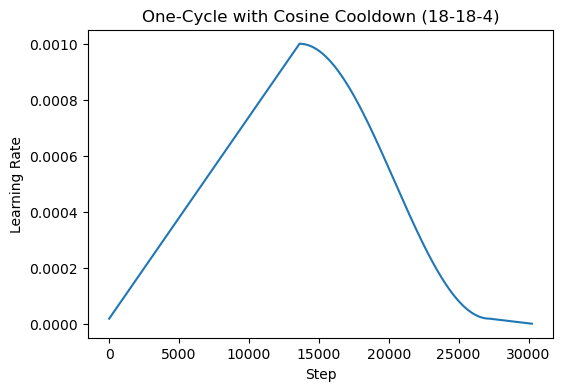

In [24]:

lrs = schedule_lr.get_curve()
plt.figure(figsize=(6,4))
plt.plot(lrs)
plt.xlabel("Step")
plt.ylabel("Learning Rate")
#plt.yscale('log')
plt.title("One-Cycle with Cosine Cooldown (18-18-4)")
plt.show()


### Momentum scheduler init

In [25]:
schedule_mom = OneCycleSchedule(1e-3, steps_per_epoch,
                                warmup_epochs=18,
                                cooldown_epochs=18,
                                annihilation_epochs=4,
                                momentum=True,           # << flip!
                                max_mom=0.95, min_mom=0.85)

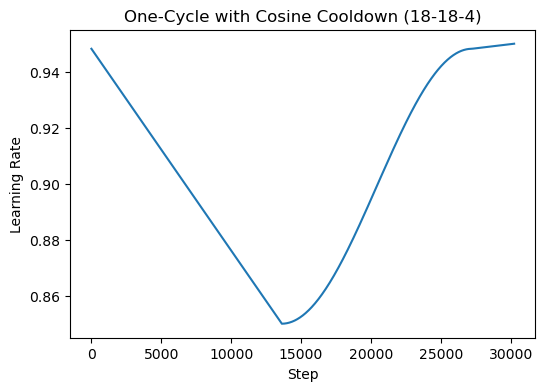

In [26]:

lrs = schedule_mom.get_curve()
plt.figure(figsize=(6,4))
plt.plot(lrs)
plt.xlabel("Step")
plt.ylabel("Learning Rate")
#plt.yscale('log')
plt.title("One-Cycle with Cosine Cooldown (18-18-4)")
plt.show()


## Trainer init

In [27]:
strategy = tf.distribute.MirroredStrategy()
num_gpus = strategy.num_replicas_in_sync
print(f"Number of devices: {num_gpus}")

Number of devices: 4


In [28]:
from importlib import reload
#reload(Trainer)
with strategy.scope():  
    NFObject: Trainer.Trainer = Trainer.Trainer(base_distribution = base_dist,
                                            flow = MAF, 
                                            x_data_train = x_train_ds,
                                            y_data_train = y_train_ds,
                                            io_kwargs = get_io_kwargs(path_to_results = path_to_results),
                                            compiler_kwargs = get_compiler_kwargs(lr = lr,
                                                                                  beta_1_scheduler=schedule_mom,
                                                                                  ignore_nans = True,
                                                                                  nan_threshold = nan_threshold),
                                            callbacks_kwargs = get_callbacks_kwargs(checkpoint_path = checkpoint_path,
                                                                                    es_min_delta = es_min_delta,
                                                                                    es_patience = es_patience,
                                                                                    lr_reduce_factor = lr_reduce_factor,
                                                                                    lr_min_delta = lr_min_delta,
                                                                                    lr_patience = lr_patience,
                                                                                    min_lr = min_lr,
                                                                                    batch_size = batch_size,
                                                                                    spline_knots = spline_knots,
                                                                                    range_min = range_min,
                                                                                    x_train = x_train_ds,
                                                                                    y_train = y_train_ds,
                                                                                    ndims = ndims,
                                                                                    total_steps = total_steps,
                                                                                    warmup_epochs = warmup_epochs,
                                                                                    cooldown_epochs = cooldown_epochs,
                                                                                    annihilation_epochs = annihilation_epochs,),
                                            fit_kwargs = get_fit_kwargs(batch_size = batch_size,
                                                                        epochs_input = epochs_input,
                                                                        validation_data = (x_val_ds, y_val_ds),
                                                                        shuffle = shuffle,
                                                                        verbose = verbose_trainer),
                                            debug_print_mode = debug_print_mode)
trainable_params: int = NFObject.trainable_params
non_trainable_params: int = NFObject.non_trainable_params

********************************************found custom MAF
********************** using conditionals in a chain *********************


Model defined.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 36)]              0         
                                                                 
 log_prob (LogProbLayer)     (None,)                   407344    
                                                                 
Total params: 407,344
Trainable params: 407,344
Non-trainable params: 0
_________________________________________________________________
Model summary:  None
self.optimizer_config: {'class_name': 'Adam', 'config': {'learning_rate': 5e-05, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': True, 'clipnorm': None, 'clipvalue': None}}
optimizer: <keras.optimizers.legacy.adam.Adam object at 0x7f65b15e1a10>
type(optimizer): <class 'keras.optimizers.legacy.adam.Adam'>
beta_1 set to scheduler function.
Model successfully compiled.
No weights found in outputs/run_5

In [29]:
#model = NFObject.model
#optimizer = NFObject.optimizer
#loss_fn = NFObject.loss
#train_ds = tf.data.Dataset.zip((x_train_ds, y_train_ds))
#
#lr_find = LrFinder(model, optimizer, loss_fn)
#lr_find.range_test(train_ds, 
#                   start_lr=1e-6, end_lr=1e-2, num_iter=100)
#lr_find.plot_lrs()

Avrei poi una domanda un po' specifica per ⁠Riccardo Torre. Si ricorda se c'è qualche ragione per cui nella classe Trainer non ha inserito la possibilità di avetre ottimizzatori di tipo tf.keras.optimizers.legacy.Optimizer ma solo di tipo tf.keras.optimizers.Optimizer ? Perchè nel notebook tutorial usava come argomento del dizionario 'Custom>Adam' che però nel codice non trovo, quindi penso che tensorflow ricada su un oggetto di alto livello che non ha alcuni metodi privati che mi servirebbero. Provando a passare semplicemente 'Adam' al Trainer incappo in un errore perchè l'ottimizzatore è del tipo non supportato. 

Le chiedo perché nel messaggio di errore è menzionato il tipo corretto (quello che serve a me):
ValueError: optimizer is not of type tf.keras.optimizers.Optimizer or tf.keras.optimizers.legacy.Optimizer.
non vorrei che lo avesse messo fra quelli possibili e poi lo avesse tolto per qualche tipo di incompatibilità

In [30]:
optimizer_config = get_compiler_kwargs(0.1,False,0.001).get("optimizer")
#print(isinstance(optimizer_config, (str,dict)))
print(f"optimizer_config: {optimizer_config}")
optimizer = tf.keras.optimizers.get(optimizer_config)
print(f"Optimizer: {optimizer}")
print(isinstance(optimizer, tf.keras.optimizers.legacy.Adam))
print(isinstance(optimizer, tf.keras.optimizers.Adam))
print(isinstance(optimizer, tf.keras.optimizers.legacy.Optimizer))

optimizer_config: {'class_name': 'Adam', 'config': {'learning_rate': 0.1, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': True, 'clipnorm': None, 'clipvalue': None}}
Optimizer: <keras.optimizers.legacy.adam.Adam object at 0x7f65abfe9090>
True
False
True


In [31]:
opt = NFObject.optimizer
opt._set_hyper("beta_1", lambda: schedule_mom(opt.iterations))
print(opt)
print(f"Optimizer: {opt.get_config()}")

Optimizer: {'name': 'Adam', 'learning_rate': 5e-05, 'decay': 0.0, 'beta_1': <tf.Tensor: shape=(), dtype=float32, numpy=0.94819635>, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': True}


In [32]:
try:   
    print('inside the first path')                                  # tf.Variable path
    beta1_val = float(opt.beta_1.numpy())
except Exception:
    try:                                 # _hyper dict path
        print('inside the second path')      
        beta1_val = float(opt._hyper["beta_1"])
    except Exception:
        print('inside the third path')      
        beta1_val = float(getattr(opt, "beta_1", 0.0))
print(beta1_val)

inside the first path
0.9481963515281677


In [33]:
config = {'mom' : schedule_mom}
scheduler = config.get('mom', None)
print(scheduler)
opt = NFObject.optimizer
opt._set_hyper("beta_1", lambda: scheduler(opt.iterations))
print(f"Optimizer: {opt.get_config()}")

Optimizer: {'name': 'Adam', 'learning_rate': 5e-05, 'decay': 0.0, 'beta_1': <tf.Tensor: shape=(), dtype=float32, numpy=0.94819635>, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': True}


## Store/save hyperparameters

In [34]:
### Initialize dictionaries to store paramerers and results ###
results_dict: Dict[str, Any] = Utils.init_results_dict()
hyperparams_dict: Dict[str, Any] = Utils.init_hyperparams_dict()

### Create log file ###
log_file_name: str = Utils.create_log_file(mother_output_dir, results_dict)

In [35]:
## data is organized in datasets, the number of samples is a bit difficult to access, need to be infered from the cache file
nsamples_train: int = 0 
nsamples_val: int = 0
nsamples_test: int = 0  # No test set in this example

## seeds not used in this example, but can be set for reproducibility
seed_train: int = 42
seed_test: int = 42
seed_dist: int = 42
seed_metrics: int = 42

hyperparams_dict = Utils.update_hyperparams_dict(hyperparams_dict = hyperparams_dict,
                                                 run_number = run_number,
                                                 n_runs = n_runs,
                                                 seeds = [seed_train, seed_test, seed_dist, seed_metrics],
                                                 nsamples = [nsamples_train, nsamples_val, nsamples_test],
                                                 ndims = ndims,
                                                 corr = None,
                                                 bijector_name = bijector_name,
                                                 nbijectors = num_bijectors,
                                                 spline_knots = spline_knots,
                                                 range_min = range_min,
                                                 hllabel = '-'.join(str(e) for e in n_hidden),
                                                 trainable_parameters = trainable_params,
                                                 non_trainable_parameters = non_trainable_params,
                                                 batch_size = batch_size,
                                                 epochs_input = epochs_input,
                                                 activation = activation,
                                                 regulariser = regulariser,
                                                 eps_regulariser = eps_regulariser,
                                                 training_device = training_device)
Utils.save_hyperparams_dict(path_to_results, hyperparams_dict)

Running 53/1 with hyperparameters:
timestamp = 2025-11-24 23:02:06.469587
ndims = 10
seed_train = 42
nsamples_train = 0
nsamples_val = 0
nsamples_test = 0
bijector = MsplineN
nbijectors = 4
spline_knots = 8
range_min = -14
hidden_layers = 128-128
trainable_parameters = 407344
epochs_input = 40
batch_size = 60000
activation = relu
training_device = NVIDIA L40S



# Train

In [36]:
#NFObject.train()

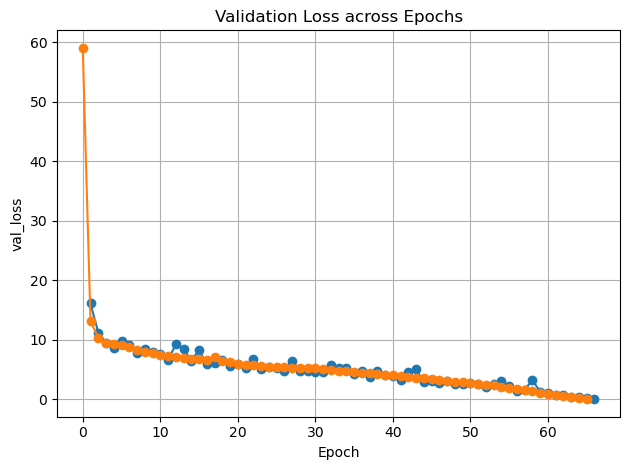

In [37]:

import re
import matplotlib.pyplot as plt

# Parse run.log
log_path = './outputs/run_{}/full_run_{}.log'.format(run_number, run_number)
#log_path = './outputs/run_{}/10k_events_run.log'.format(run_number)
epochs = []
val_losses = []
lrs = []
loss = []

with open(log_path, 'r') as f:
    lines = f.readlines()

current_epoch = None
for line in lines:
    if line.strip().startswith("Epoch") and "/" in line:
        m = re.match(r"Epoch\s+(\d+)/\d+", line.strip())
        if m:
            current_epoch = int(m.group(1))
    if "- lr:" in line and "val_loss:" in line:
        val_loss_match = re.search(r"val_loss:\s+([0-9.]+)", line)
        loss_match = re.search(r"loss:\s+([0-9.]+)", line)
        lr_match = re.search(r"lr:\s+([0-9.eE+-]+)", line)
        if val_loss_match and lr_match and loss_match and current_epoch is not None:
            val_losses.append(float(val_loss_match.group(1)))
            loss.append(float(loss_match.group(1)))
            lrs.append(float(lr_match.group(1)))
            epochs.append(current_epoch)

# Plot val_loss vs epoch
plt.figure()
plt.plot(epochs, val_losses, loss, marker='o')
plt.title("Validation Loss across Epochs")
plt.xlabel("Epoch")
plt.ylabel("val_loss")
#plt.yscale('log')
plt.grid(True)
plt.tight_layout()


## Weights histogram

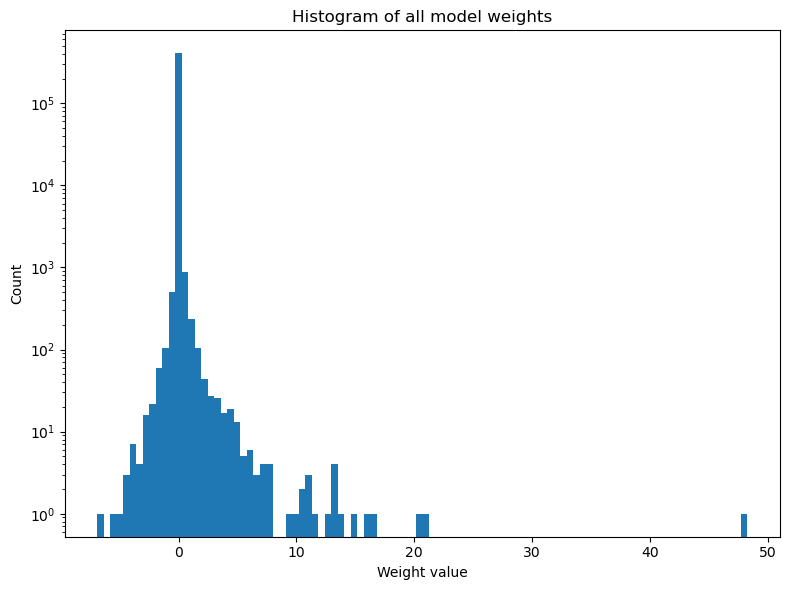

In [38]:
# 1. Grab all trainable variables from your Keras model
#    (this will include every weight/bias in your MAF/RQS networks,
#     because TFP tracks them as part of the model once you called fit)
vars = NFObject.model.trainable_weights

# 2. Pull them out as a flat NumPy array
all_w = np.concatenate([w.numpy().ravel() for w in vars])

# 3. Plot
plt.figure(figsize=(8,6))
plt.hist(all_w, bins=100)
plt.xlabel("Weight value")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Histogram of all model weights")
plt.tight_layout()
plt.show()

# Sampling



## Building Preprocessed test dataset
Reads the test dataset and builds the new test dataset. added the flag `E_coarse_max_ref` but I still don't know if i need to use it, if E_max from the first dataset is less than the max in this new dataset we could have some problem in the logarithms

In [39]:
MODE = 'A'
showers_raw, cs, E_inc, fine_flat, cond_flat, factors = Preprocess2.build_and_cache(
    raw_h5     = "/teo_fs_fast/users/acosso/Dataset/dataset_2_2.hdf5",
    cache_file = "/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    mode       = MODE,
    E_coarse_max_ref = None,  # Set to None to use the maximum from the dataset
    force_rebuild = False,
    verbose = True, 
    noise_scale=1e-4,
    compression = 'lzf'
)

[build_and_cache] Loading from cache.


In [40]:

# 1) load cond_flat from your cache
cache_file = "/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5"

# 2) pick an event
event_id = 7
mode = 'A'
cond_event, incident_energy, coarse_E_flat = Sample.get_conditional_event(cache_file, mode , event_id, dtype = tf.float64)  # [V, C]
print("cond_event shape:", tf.shape(cond_event))
print("is cond_event nan?", tf.reduce_any(tf.math.is_nan(cond_event)))

# 3) sample
fine_samples = Sample.sample_event(flow = MAF, base_dist=base_dist, cond_event=cond_event, clip_latent= False, latent_clip_value=4.0, verbose=False)
print("fine samples min:", fine_samples.numpy().min(), "max:", fine_samples.numpy().max())
#original_full_calo = Sample.invert_log_standardize_from_cache(fine_samples,cache_file) 

if mode == 'B':
    zf, af, rf = 1, 4, 3  # from your factors
elif mode == 'A':
    zf, af, rf = 5, 2, 1
else:
    raise ValueError(f"Unknown mode: {mode}. Expected 'A' or 'B'.")

cond_event shape: tf.Tensor([648  31], shape=(2,), dtype=int32)
is cond_event nan? tf.Tensor(False, shape=(), dtype=bool)


ValueError: Exception encountered when calling layer 'model_7' (type Functional).

Input 0 of layer "dense_29" is incompatible with the layer: expected axis -1 of input shape to have value 26, but received input with shape (648, 31)

Call arguments received by layer 'model_7' (type Functional):
  • inputs=['tf.Tensor(shape=(648, 10), dtype=float64)', 'tf.Tensor(shape=(648, 31), dtype=float64)']
  • training=None
  • mask=None

In [ ]:
from importlib import reload
reload(Sample)
# 4) Invert preprocessing
fine_samples_inverted = Sample.invert_transform_fine(fine_samples,
                                           coarse_E_flat,
                                           alpha=1e-6,
                                           dtype=tf.float64)

# 5) reshape for plotting
full_calo = Sample.reshape_to_calo_flat(fine_samples_inverted, mode=MODE)

## Comparing Sampled distribution with the original from the same event.

In [ ]:
# Pull out the “truth” shower from Geant4 using the parameters used to extracs the conditional tensor.:
original_shower, e_inc = Plot_helper.get_original_shower(cache_file, event_id)  # tf.Tensor [1,6480]

# Verify the incident energy in the first layer’s “center cell.”
# (If you want to double‐check that this matches the cond_event’s E_event, for consistency:)

print("Truth E_inc (from the first fine‐voxel):", e_inc)
incident_energy = (10**incident_energy)*(10**4.5) # revert the preprocessing steps
print("incident energy in cond_event:", incident_energy.numpy())
print("original shower shape:", original_shower.shape)


Truth E_inc (from the first fine‐voxel): 121936.8671875
incident energy in cond_event: 121936.88305085285
original shower shape: (1, 6480)


train_arr shape: (1, 6480)


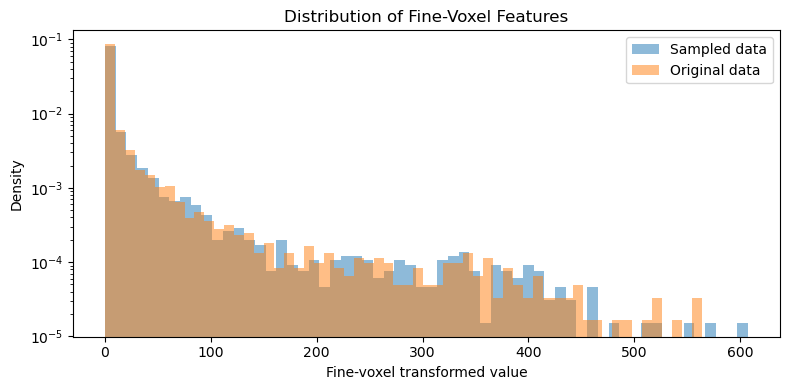

In [ ]:
def plot_fine_feature_distribution(
    x: Union[tf.Tensor, np.ndarray], 
    original_shower: Union[tf.Tensor, np.ndarray],
    fine_dim: int,
    nbins: int = 100
):
    """
    Plot histograms of *only* the first `fine_dim` columns (the fine-voxel energies)
    from your concatenated training/validation tensors.

    Args:
      x_train: tf.Tensor or np.ndarray, shape [N_train, D_total]
      x_val:   tf.Tensor or np.ndarray, shape [N_val,   D_total]
      fine_dim: int, number of fine-voxel features at the start of each row
      nbins:   number of histogram bins
    """
    # Convert to numpy if needed
    if isinstance(x, tf.Tensor):
        train_arr = x.numpy()
        original_shower = original_shower.numpy()
    else:
        train_arr = np.array(x)
        original_shower = np.array(original_shower)

    print("train_arr shape:", train_arr.shape)

    plt.figure(figsize=(8, 4))
    plt.hist(train_arr[0], bins=nbins, alpha=0.5, density=True, label="Sampled data")
    plt.hist(original_shower[0], bins=nbins, alpha=0.5, density=True, label="Original data")
    plt.xlabel("Fine-voxel transformed value")
    plt.ylabel("Density")
    plt.yscale('log')
    plt.title("Distribution of Fine-Voxel Features")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_fine_feature_distribution(full_calo, original_shower= original_shower, fine_dim=12, nbins=60)


## Plot

In [ ]:
print(full_calo.min(), full_calo.max())

0.0 607.3387919211965


In [ ]:
HLF_2.CalculateFeatures(full_calo)
_ = HLF_2.DrawSingleShower(full_calo[0], filename=None, title="Single Electron shower at {:.1f} MeV".format(incident_energy))

## Comparing generated data with the Geant4 event 

In [ ]:
Plot_helper.plot_two_showers(full_calo, cache_file, event_id,hlf=HLF_2)

In [ ]:
Plot_helper.plot_residual(full_calo,cache_file = cache_file,event_id = event_id,hlf=HLF_2)

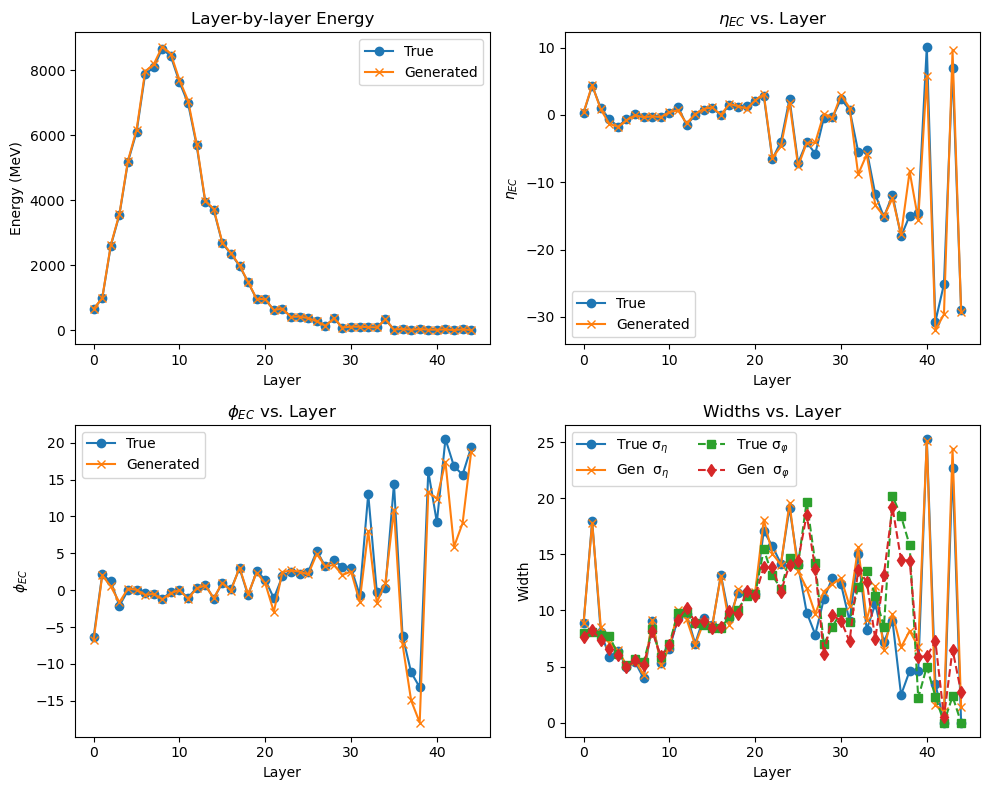

In [ ]:
from importlib import reload
reload(Plot_helper)
Plot_helper.plot_scalar_quantities(full_calo, cache_file = cache_file, event_id = event_id, hlf = HLF_2)

Event 7 Summary Metrics:
  • True E_tot       = 94878.758 MeV
  • Generated E_tot  = 95748.420 MeV
  • ΔE_tot           = 869.662 MeV

  • Layer-wise MSE:

  • Centroid shifts (η, φ) per layer:

  • KS statistic on full voxel distribution: D = 0.6904, p-value = 0.0000


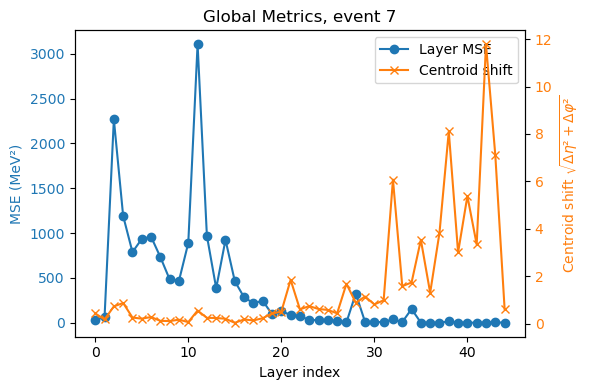

In [ ]:
Plot_helper.plot_global_summary_metrics(full_calo, cache_file = cache_file, event_id = event_id, hlf = HLF_2)

The four panels show complementary aspects of angular continuity across layers:

1. **Angular centroid per layer** — energy-weighted mean angle $\bar\phi_l$ in each layer, comparing true vs. generated showers. Smooth evolution indicates consistent angular development.
2. **|Δφ| between adjacent layers** — absolute change in centroid angle from layer $l$ to $l{+}1$. Large jumps (>90°) reveal unphysical flips of the shower direction.
3. **Max correlation of angular profiles** — similarity of the full angular distributions between neighboring layers, allowing for circular shifts. High correlation means layer-to-layer angular structure is preserved.
4. **Per-layer centroid error** — absolute difference between generated and true centroids. This measures how well the generator reproduces the angular position of the shower in each layer.


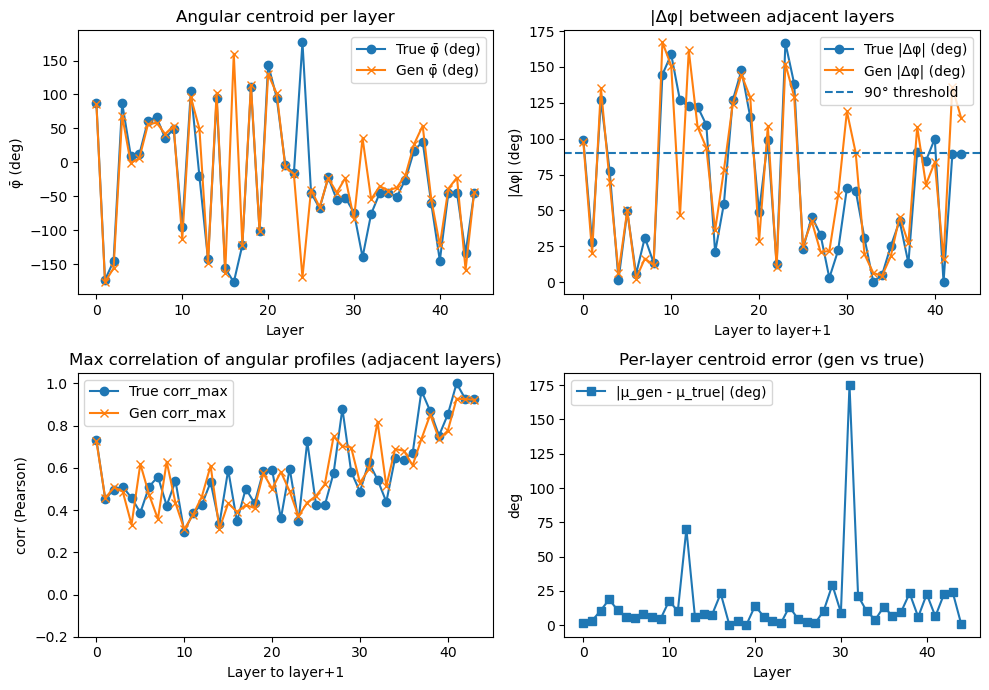


Angular continuity (Generated): {'mean_|Δφ|_deg': 70.62443784813865, 'mean_profile_corr_max': 0.5715531248885434, 'mean_|ΔR|': 0.16233564890491847, 'flip_fraction_90': 0.4090909090909091}
Angular continuity (True):      {'mean_|Δφ|_deg': 67.60404125905876, 'mean_profile_corr_max': 0.5759436643936418, 'mean_|ΔR|': 0.16425834800688757, 'flip_fraction_90': 0.36363636363636365}
Gen vs True (per-layer):       {'mean_|μ_gen-μ_true|_deg': 14.72067786921634, 'mean_profile_corr_same_layer': 0.7033113441673159}


In [ ]:
metrics = Plot_helper.plot_angular_continuity_metrics(
    full_calo, cache_file=cache_file, event_id=event_id, normalize_profiles=True,
    save_prefix=None  # or "/path/to/figs/"
)


# Metrics


## How do Gmetrics work?
it wants a callable function that returns the requested number of samples. If the input module asks for n samples, the shape should be (n,d) where d is the number of features. 

- **Option A**: Per-Coarse voxel metrics
we compare the energy distribution in the generated fine voxels vs the true, original, ones.

-  **Option B**: Per-event physical features
    - energy distribution of the whole shower
    - energy fractions in the layers
    - radial distribution
    - angular distribution
    - moments (mean, stddev...)

In [ ]:
import GMetrics # type: ignore
from GMetrics.plotters import plot_corners, cornerplotter, plot_corr_matrix, plot_corr_matrix_side_by_side # type: ignore
from GMetrics.more import deformations # type: ignore
from GMetrics.more.optimizers_deformations import compute_exclusion_bisection, compute_exclusion_LR_bisection # type: ignore
from GMetrics.utils import se_mean, se_std
from GMetrics.notebooks import shared
try:
    from GMetrics.base import NumpyDistribution
except ImportError:
    try:
        from GMetrics.more import NumpyDistribution
    except ImportError:
        from GMetrics.utils import NumpyDistribution

import pandas as pd

## Null hypothesis

In [ ]:
batch_size_test = 5_000

In [ ]:
model_dir = path_to_results
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


In [ ]:
Df = int(ndims)  # e.g. 10 in Mode A or 12 in Mode B

placeholder_dist = tfd.MultivariateNormalDiag(
    loc=tf.zeros([Df], tf.float64),
    scale_diag=tf.ones([Df], tf.float64),
    name="placeholder"
)


In [ ]:
# --- Load aligned flats from your cache (same order everywhere) ---
with h5py.File("/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5", "r") as f:
    cond_bank_np   = f["cond_trans"][...]     # [TOTAL, C]
    fine_bank_np   = f["fine_trans"][...]     # [TOTAL, Df]  (logit/transformed space)
    coarse_np      = f["coarse_showers"][...] # [N, nz, na, nr]
    factors_np     = f["factors"][...]        # e.g. [zf, af, rf]

N, nz, na, nr = coarse_np.shape
V     = nz * na * nr
TOTAL = N * V
Df    = fine_bank_np.shape[1]
C     = cond_bank_np.shape[1]

with tf.device("/CPU:0"):
    cond_bank   = tf.constant(cond_bank_np, dtype=tf.float64)             # [TOTAL, C]
    fine_bank   = tf.constant(fine_bank_np, dtype=tf.float64)             # tr[TOTAL, Df]
    coarse_bank = tf.constant(coarse_np.reshape(TOTAL), dtype=tf.float64) # [TOTAL]

In [ ]:
# Per-voxel sampler (pure TF) – mirrors your Sample.sample_event forward path
@tf.function(jit_compile=False)
def sample_logits_from_conditions(flow, base_dist, conds, clip_latent=False, latent_clip_value=4.0):
    """
    Per-voxel sampler mirroring Sample.sample_event, but for arbitrary batch conds [n, C].
    Returns logits in the fine-voxel space with shape [n, Df].
    """
    n = tf.shape(conds)[0]                   # number of voxels to sample
    z = base_dist.sample(sample_shape=n)     # [n, Df]
    if clip_latent:
        z = tf.clip_by_value(z, -latent_clip_value, +latent_clip_value)

    x = z
    # Identical conditional routing as in Sample.sample_event
    for bij in reversed(flow.bijectors):
        cond_fn = getattr(bij, "_shift_and_log_scale_fn", None)
        is_conditional = getattr(cond_fn, "_conditional", False)
        x = bij.forward(x, conditional_input=conds) if is_conditional else bij.forward(x)

    return tf.ensure_shape(tf.cast(x, tf.float64), [None, Df])  # logits

In [ ]:
# Enable TF memory growth so the runtime doesn’t pre-grab all GPU memory
for g in tf.config.list_physical_devices("GPU"):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

In [ ]:
# Shared, deterministic index vector (wrap if Ns > TOTAL)
niter = 10_000
Ns = niter * batch_size_test
idx_all = tf.range(Ns, dtype=tf.int32) % TOTAL

CHUNK = 10_000  # lower if needed (10k, 5k…)

def build_numeric_banks_chunked(idx_all, chunk=CHUNK):
    n_total = int(idx_all.shape[0])
    truth_chunks, model_chunks = [], []

    for start in range(0, n_total, chunk):
        end = min(start + chunk, n_total)
        idx = idx_all[start:end]

        # ---- TRUTH chunk ----
        fine_logits_true = tf.gather(fine_bank, idx)
        coarse_true      = tf.gather(coarse_bank, idx)
        truth_E_chunk    = Sample.invert_transform_fine(
            fine_logits_true, coarse_true, alpha=1e-6, dtype=tf.float64
        )
        with tf.device("/CPU:0"):
            truth_chunks.append(tf.identity(truth_E_chunk))

        # ---- MODEL chunk ----
        conds_chunk   = tf.gather(cond_bank, idx)
        coarse_model  = tf.gather(coarse_bank, idx)
        logits_chunk  = sample_logits_from_conditions(flow=MAF, base_dist=base_dist,
                                                      conds=conds_chunk, clip_latent=False, 
                                                      latent_clip_value=4.0,
                                                      )
        model_E_chunk = Sample.invert_transform_fine(
            logits_chunk, coarse_model, alpha=1e-6, dtype=tf.float64
        )
        with tf.device("/CPU:0"):
            model_chunks.append(tf.identity(model_E_chunk))

    with tf.device("/CPU:0"):
        dist_1_num = tf.concat(truth_chunks, axis=0)   # [Ns, Df] on CPU
        dist_2_num = tf.concat(model_chunks, axis=0)   # [Ns, Df] on CPU
    return dist_1_num, dist_2_num 

dist_1_num, dist_2_num = build_numeric_banks_chunked(idx_all, chunk=CHUNK)


InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run GatherV2: Dst tensor is not initialized. [Op:GatherV2]

In [ ]:

TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = placeholder_dist,
                                                   dist_2_input = placeholder_dist,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 5_000,
                                                   small_sample_threshold = 1e7,
                                                   dtype_input = tf.float64,
                                                   seed_input = seed_test,
                                                   use_tf = True, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a tfp.distributions.Distribution object.
Parsing input distribution...
Input distribution is a tfp.distributions.Distribution object.
Checking and setting numerical distributions.
Resetting dist_num.
Resetting dist_num.
nsamples 50000000
batch_size 5000
niter 10000
niter * batch_size 50000000
small_sample False


In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = 100, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = 100, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)
FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = 20, # to be included in metric kwargs
                               num_points = 10, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
LRMetric = GMetrics.LRMetric(TwoSampleTestInputs,
                             null_test=True,
                             verbose = True)

Generating random directions based on nslices, ndims, and seed_slicing.
Generating random directions based on nslices, ndims, and seed_slicing.
To run under the alternative hypothesis, set the `null_test` attribute to False.


### Set up tests and metrics configurations

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

ncomp = 1
test_config_null["ncomp"] = ncomp

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,...,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample,ncomp
0,10000,5000,5000,10000000,float64,42,True,False,None,True,...,10,0,True,10,0,float64,10,50000000,False,1


In [ ]:
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_ncop_"+str(ncomp)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {"fgd": {"name": "fgd",
                                       "object_name": "FGDMetric",
                                       "class_name": "GMetrics.FGDMetric",
                                       "kwargs": {"num_batches": 20,
                                                  "num_points": 10,
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 100, # optimized for 5D
                                       "latex": "$t_{\mathrm{FGD}}$",
                                       "null_file": null_hypotheses_dir+"FGD.json"},
                               "mmd": {"name": "mmd",
                                       "object_name": "MMDMetric" ,
                                       "class_name": "GMetrics.MMDMetric",
                                       "kwargs": {"degree": 4, 
                                                  "block_size": 10_000, 
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 2, # optimized for 5D
                                       "latex": "$t_{\mathrm{MMD}}$",
                                       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": 100, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": 100, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"},
                               "lr": {"name": "lr",
                                       "object_name": "LRMetric",
                                       "class_name": "GMetrics.LRMetric", 
                                       "kwargs": {"null_test": True},
                                       "result_key": "lik_ratio_norm_list", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 50,
                                       "latex": "$t_{\mathrm{LLR}}$",
                                       "null_file": null_hypotheses_dir+"LR.json"}}}
#metrics_config[unique_key]

### Evaluate null hypotheses

In [ ]:
for metric in list(metrics_config[unique_key].values())[:-1]:
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric["max_vectorize"]
    obj = eval(metric["object_name"])
    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and savng {name} with max_vectorize = {max_vectorize}")
        obj.Test_tf(max_vectorize=max_vectorize)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)

Computing and savng fgd with max_vectorize = 100

------------------------------------------
Starting FGD metric calculation...
Running TF FGD calculation...
niter = 10000
batch_size = 5000
The dist_1_num tensor is empty. Batches will be generated 'on-the-fly' from dist_1_symb.
The dist_2_num tensor is empty. Batches will be generated 'on-the-fly' from dist_2_symb.
nchunks = 100
Iterating from 0 to 100 out of 10000 .
Iterating from 100 to 200 out of 10000 .
Iterating from 200 to 300 out of 10000 .
Iterating from 300 to 400 out of 10000 .
Iterating from 400 to 500 out of 10000 .
Iterating from 500 to 600 out of 10000 .
Iterating from 600 to 700 out of 10000 .
Iterating from 700 to 800 out of 10000 .
Iterating from 800 to 900 out of 10000 .
Iterating from 900 to 1000 out of 10000 .
Iterating from 1000 to 1100 out of 10000 .
Iterating from 1100 to 1200 out of 10000 .
Iterating from 1200 to 1300 out of 10000 .
Iterating from 1300 to 1400 out of 10000 .
Iterating from 1400 to 1500 out of 10

Iterating from 1600 to 1700 out of 10000 .
Iterating from 1700 to 1800 out of 10000 .
Iterating from 1800 to 1900 out of 10000 .
Iterating from 1900 to 2000 out of 10000 .
Iterating from 2000 to 2100 out of 10000 .
Iterating from 2100 to 2200 out of 10000 .
Iterating from 2200 to 2300 out of 10000 .
Iterating from 2300 to 2400 out of 10000 .
Iterating from 2400 to 2500 out of 10000 .
Iterating from 2500 to 2600 out of 10000 .
Iterating from 2600 to 2700 out of 10000 .
Iterating from 2700 to 2800 out of 10000 .
Iterating from 2800 to 2900 out of 10000 .
Iterating from 2900 to 3000 out of 10000 .
Iterating from 3000 to 3100 out of 10000 .
Iterating from 3100 to 3200 out of 10000 .
Iterating from 3200 to 3300 out of 10000 .
Iterating from 3300 to 3400 out of 10000 .
Iterating from 3400 to 3500 out of 10000 .
Iterating from 3500 to 3600 out of 10000 .
Iterating from 3600 to 3700 out of 10000 .
Iterating from 3700 to 3800 out of 10000 .
Iterating from 3800 to 3900 out of 10000 .
Iterating f

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values())[:-1]:
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)
    dist_null = np.array(obj.Results[-1].result_value[result_key])*scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
metrics_config[unique_key]["lr"]["thresholds"] = []

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

ThresholdS for metric fgd: [[0.68, [6800, 3199], 0.001167218665967992], [0.95, [9500, 500], 0.005142384775356407], [0.99, [9900, 100], 0.00771801003170435]]
Computing time for metric fgd: 359.2850727085024
ThresholdS for metric mmd: [[0.68, [6800, 3199], 0.00045073083545688064], [0.95, [9500, 500], 0.002111466658566652], [0.99, [9900, 100], 0.0031355556106151816]]
Computing time for metric mmd: 284.03393570240587
ThresholdS for metric ks: [[0.68, [6800, 3199], 0.9020003676414489], [0.95, [9500, 500], 1.0070005059242249], [0.99, [9900, 100], 1.0710002481937408]]
Computing time for metric ks: 37.53774249088019
ThresholdS for metric sks: [[0.68, [6800, 3199], 0.8906002156436443], [0.95, [9500, 500], 0.9777002036571503], [0.99, [9900, 100], 1.0304003022611141]]
Computing time for metric sks: 266.1646262984723
ThresholdS for metric swd: [[0.68, [6800, 3199], 0.42171714744195987], [0.95, [9500, 500], 0.4800137774487861], [0.99, [9900, 100], 0.5178743278830302]]
Computing time for metric swd:

,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7f041e7f6d40>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 5000, 'bat...",100,$t_{\mathrm{FGD}}$,outputs/run_53/null_hypothesis/FGD.json,"[[0.68, [6800, 3199], 0.001167218665967992], [..."
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7f041e7f6de0>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 5000, 'bat...",2,$t_{\mathrm{MMD}}$,outputs/run_53/null_hypothesis/MMD.json,"[[0.68, [6800, 3199], 0.00045073083545688064],..."
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7f041e7f53a0>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",10000,$t_{\overline{\mathrm{KS}}}$,outputs/run_53/null_hypothesis/KS.json,"[[0.68, [6800, 3199], 0.9020003676414489], [0...."
3,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f041e7f5b20>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",200,$t_{\mathrm{SKS}}$,outputs/run_53/null_hypothesis/SKS.json,"[[0.68, [6800, 3199], 0.8906002156436443], [0...."
4,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f041e7f5a80>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",200,$t_{\mathrm{SW}}$,outputs/run_53/null_hypothesis/SWD.json,"[[0.68, [6800, 3199], 0.42171714744195987], [0..."
5,lr,LRMetric,GMetrics.LRMetric,{'null_test': True},lik_ratio_norm_list,<function <lambda> at 0x7f041e7f6f20>,"lambda ns, ndims: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",50,$t_{\mathrm{LLR}}$,outputs/run_53/null_hypothesis/LR.json,[]


mu = 0.011580724363959261 +/- 3.4031333417315063e-06
sigma = 0.018447583423666924 +/- 0.0002249829346821214
68%CL = 0.01167218665967992, 95%CL = 0.051423847753564074, 99%CL = 0.0771801003170435
mu = 0.011580724363959261 +/- 3.4031333417315063e-06
sigma = 0.018447583423666924 +/- 0.0002249829346821214


/tmp/ipykernel_1976242/3122679453.py:89: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)


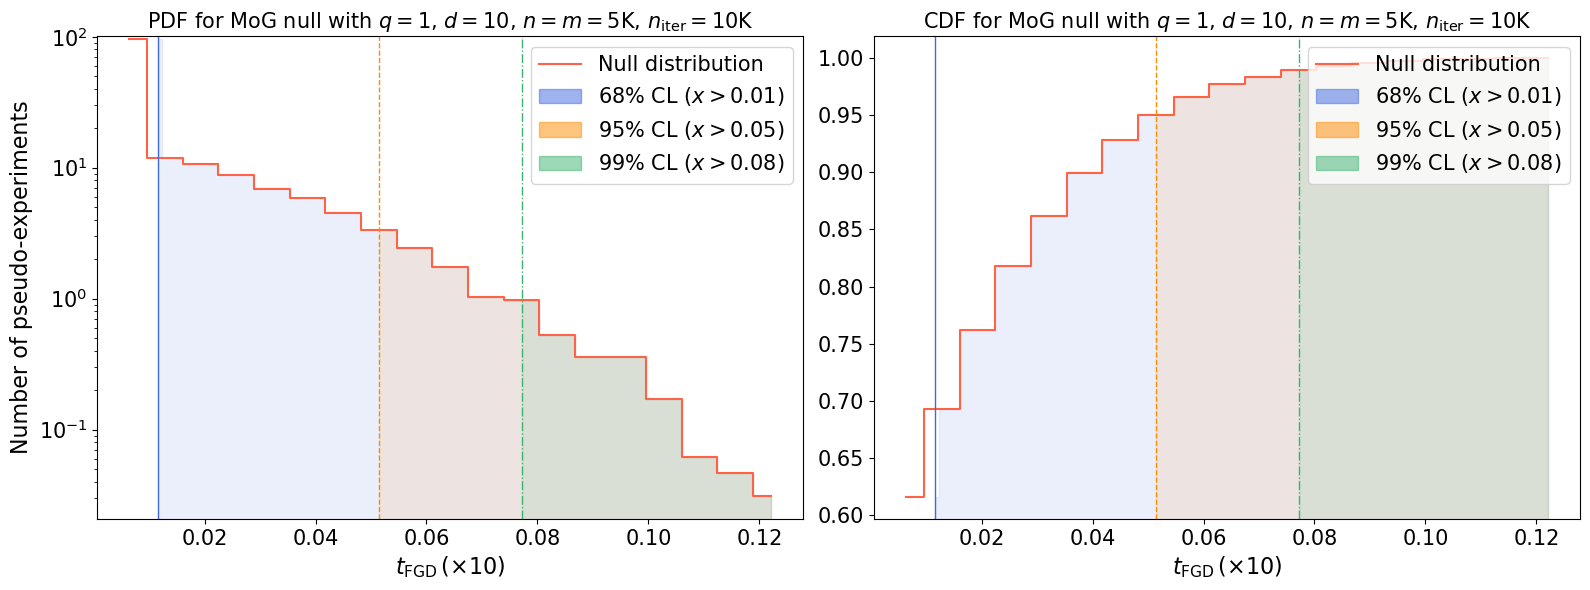

Time elapsed: 0.5622288109734654 seconds.
mu = 1.0729640576390499e-05 +/- 1.3393333583571609e-08
sigma = 0.0011572957091241464 +/- 9.456722875036042e-06
68%CL = 0.00045073083545688064, 95%CL = 0.002111466658566652, 99%CL = 0.0031355556106151816
mu = 1.0729640576390499e-05 +/- 1.3393333583571609e-08
sigma = 0.0011572957091241464 +/- 9.456722875036042e-06


/tmp/ipykernel_1976242/3122679453.py:89: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)


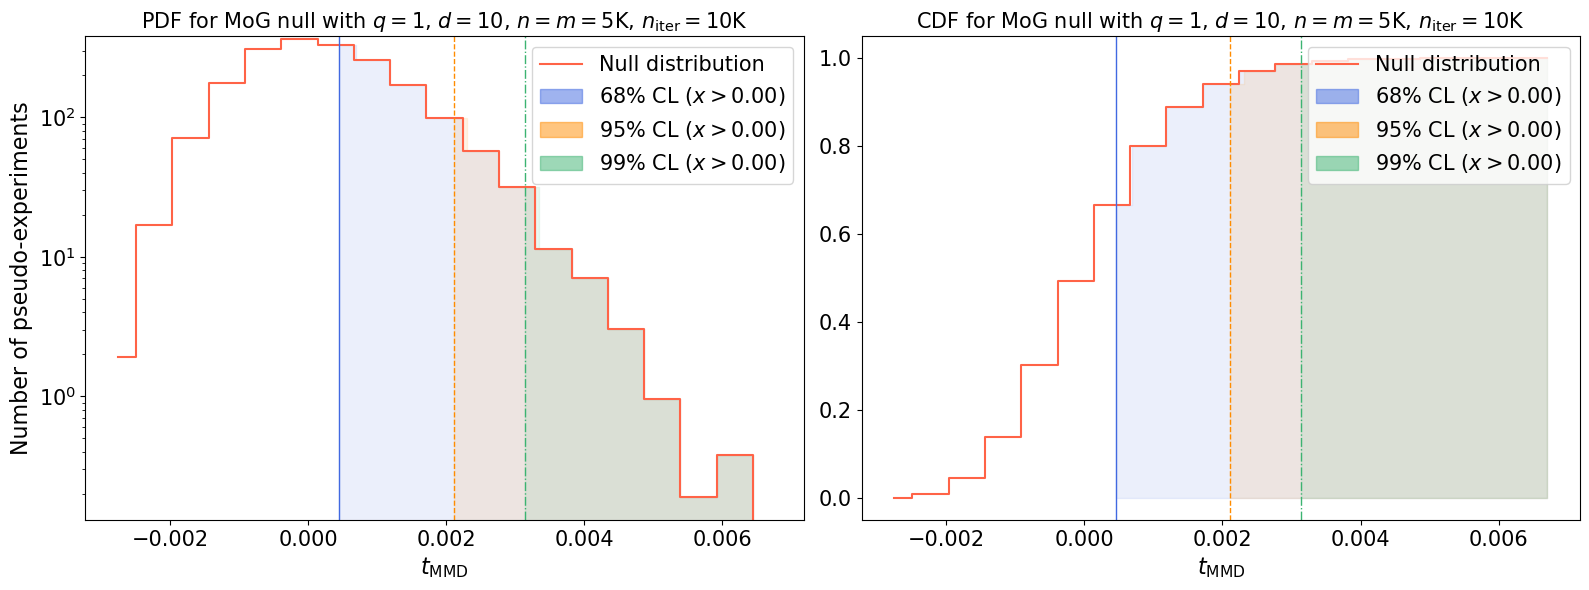

Time elapsed: 0.4435617923736572 seconds.
mu = 0.8646868451307528 +/- 6.940881018958316e-05
sigma = 0.08331195003694437 +/- 0.0005846008341916358
68%CL = 0.9020003676414489, 95%CL = 1.0070005059242249, 99%CL = 1.0710002481937408
mu = 0.8646868451307528 +/- 6.940881018958316e-05
sigma = 0.08331195003694437 +/- 0.0005846008341916358


/tmp/ipykernel_1976242/3122679453.py:89: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)


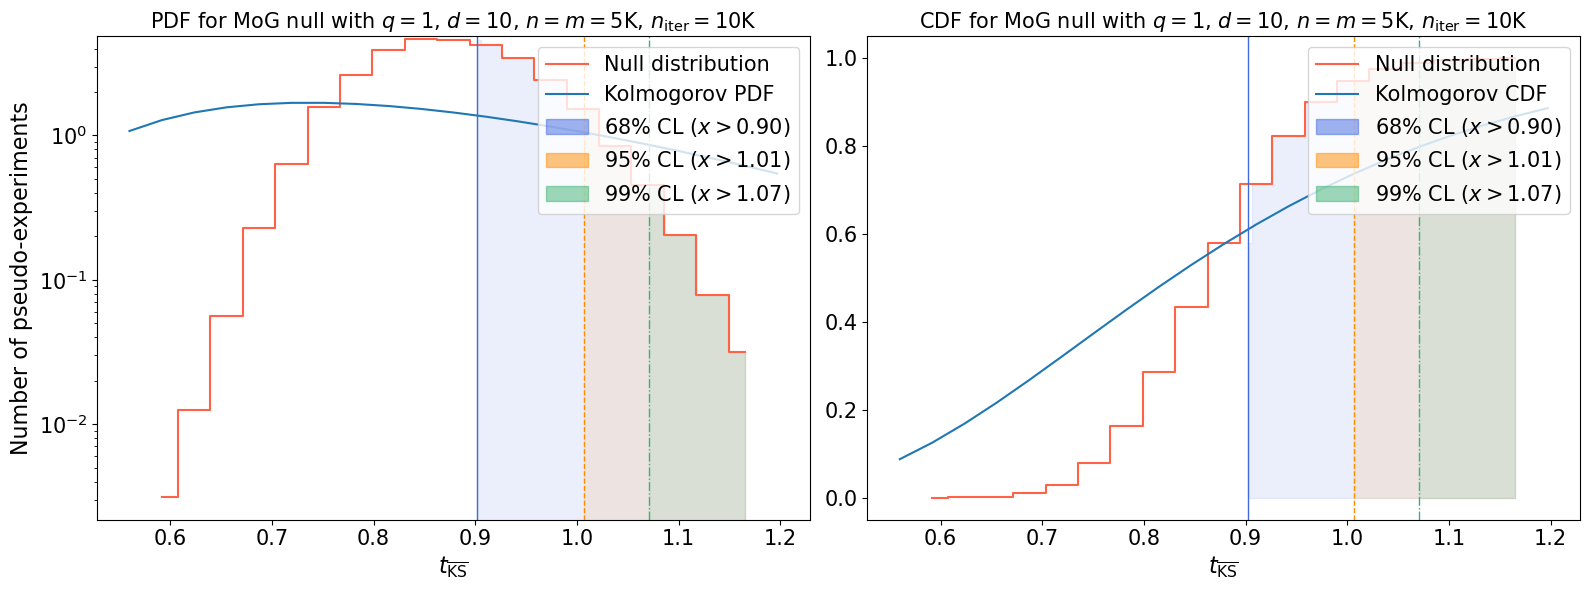

Time elapsed: 0.6130480784922838 seconds.
mu = 0.8633340962184594 +/- 4.257997041268817e-05
sigma = 0.06525332973319306 +/- 0.0004701301479625529
68%CL = 0.8906002156436443, 95%CL = 0.9777002036571503, 99%CL = 1.0304003022611141
mu = 0.8633340962184594 +/- 4.257997041268817e-05
sigma = 0.06525332973319306 +/- 0.0004701301479625529


/tmp/ipykernel_1976242/3122679453.py:89: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)


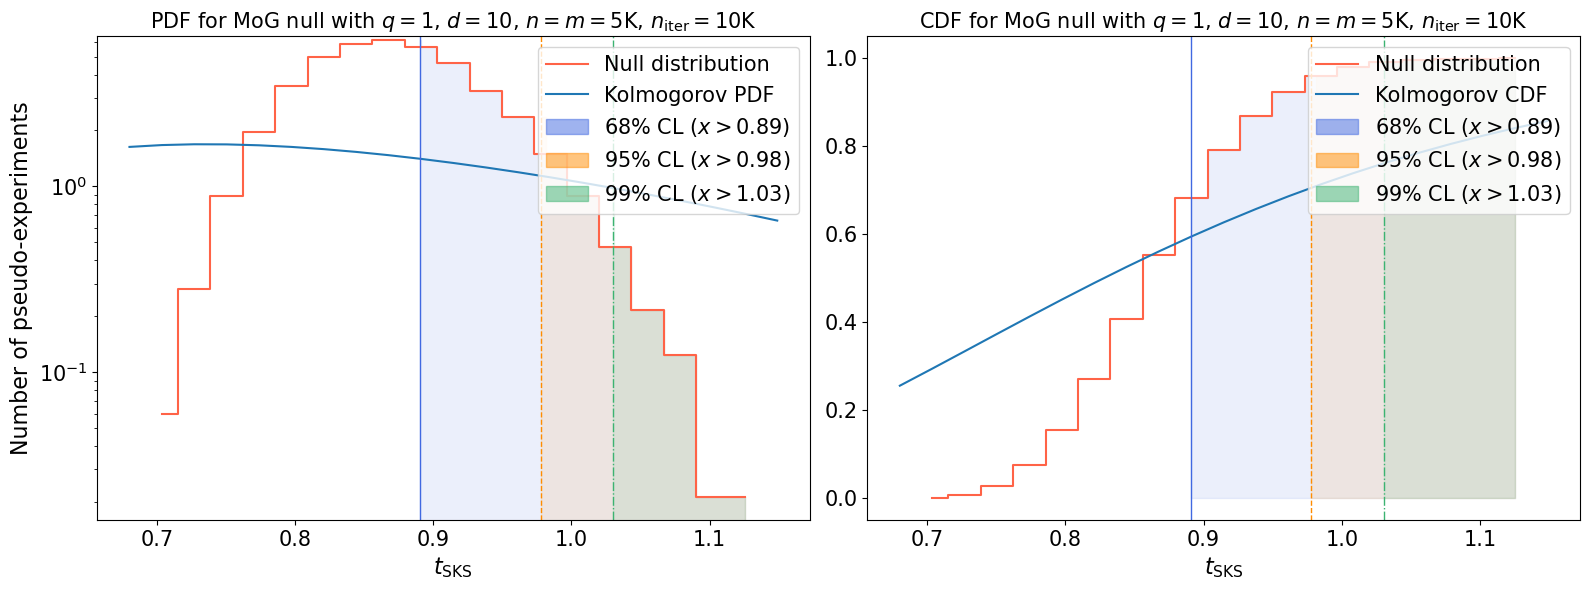

Time elapsed: 0.5831288313493133 seconds.
mu = 0.40561462569527645 +/- 1.705366481470726e-05
sigma = 0.04129608312504621 +/- 0.0003177988457084896
68%CL = 0.42171714744195987, 95%CL = 0.4800137774487861, 99%CL = 0.5178743278830302
mu = 0.40561462569527645 +/- 1.705366481470726e-05
sigma = 0.04129608312504621 +/- 0.0003177988457084896


/tmp/ipykernel_1976242/3122679453.py:89: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)


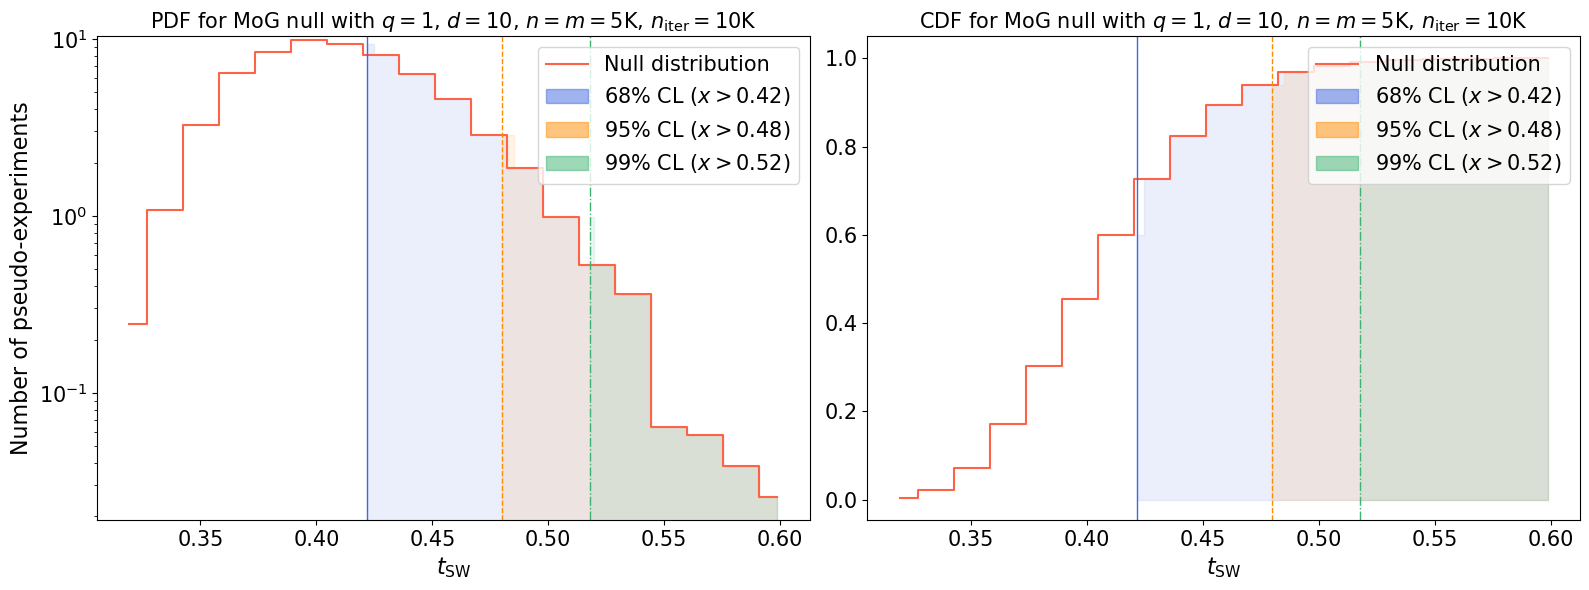

Time elapsed: 0.44673218484967947 seconds.


,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds,null_figure
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7f041e7f6d40>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 5000, 'bat...",100,$t_{\mathrm{FGD}}$,outputs/run_53/null_hypothesis/FGD.json,"[[0.68, [6800, 3199], 0.001167218665967992], [...",outputs/run_53/null_hypothesis/FGD.pdf
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7f041e7f6de0>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 5000, 'bat...",2,$t_{\mathrm{MMD}}$,outputs/run_53/null_hypothesis/MMD.json,"[[0.68, [6800, 3199], 0.00045073083545688064],...",outputs/run_53/null_hypothesis/MMD.pdf
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7f041e7f53a0>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",10000,$t_{\overline{\mathrm{KS}}}$,outputs/run_53/null_hypothesis/KS.json,"[[0.68, [6800, 3199], 0.9020003676414489], [0....",outputs/run_53/null_hypothesis/KS.pdf
3,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f041e7f5b20>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",200,$t_{\mathrm{SKS}}$,outputs/run_53/null_hypothesis/SKS.json,"[[0.68, [6800, 3199], 0.8906002156436443], [0....",outputs/run_53/null_hypothesis/SKS.pdf
4,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f041e7f5a80>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",200,$t_{\mathrm{SW}}$,outputs/run_53/null_hypothesis/SWD.json,"[[0.68, [6800, 3199], 0.42171714744195987], [0...",outputs/run_53/null_hypothesis/SWD.pdf
5,lr,LRMetric,GMetrics.LRMetric,{'null_test': True},lik_ratio_norm_list,<function <lambda> at 0x7f041e7f6f20>,"lambda ns, ndims: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 5000, 'bat...",50,$t_{\mathrm{LLR}}$,outputs/run_53/null_hypothesis/LR.json,[],NaN


In [ ]:
from timeit import default_timer as timer
from scipy.stats import kstwobign, norm

for metric in list(metrics_config[unique_key].values())[:-1]:
    name = metric["name"]
    name_cap = name.upper()
    latex = metric["latex"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    figure_file = metric["null_file"].replace("json","pdf")
    thresholds = metric["thresholds"]

    start = timer()
    
    nsamples = obj.Inputs.batch_size_test
    niter = obj.Inputs.niter
    ns = nsamples**2 /(2*nsamples)
    dist_null = np.array(obj.Results[-1].result_value[result_key])*scale_func(ns, ndims)
    if "FGD" in latex:
        latex = r"$t_{\mathrm{FGD}}\,(\times 10)$"
        dist_null = dist_null * 10
    #elif "MMD" in latex:
    #    latex = r"$t_{\mathrm{MMD}}\,(\times 10^{-2})$"
    #    dist_null = dist_null / 100
    
    scale = 'log'
    num_bins = 20  # number of bins|
    
    mu, deltamu, sigma, deltasigma = (np.mean(dist_null), se_mean(dist_null), np.std(dist_null), se_std(dist_null))
    sigma_68, sigma_95, sigma_99 = [np.sort(dist_null)[int(len(dist_null)*cl)] for cl in [0.68, 0.95, 0.99]]
    print(f"mu = {mu} +/- {deltamu}")
    print(f"sigma = {sigma} +/- {deltasigma}")
    print(f"68%CL = {sigma_68}, 95%CL = {sigma_95}, 99%CL = {sigma_99}")
    
    print("mu =", mu, "+/-", deltamu)
    print("sigma =", sigma, "+/-", deltasigma)
    
    min_x, max_x = min(dist_null), max(dist_null) # lower and upper limit of the binning
    x = np.linspace(min_x, max_x, num_bins + 1)
    counts, bin_edges = np.histogram(dist_null, bins=x, density=True)
    cum_counts = np.cumsum(counts)/np.sum(counts)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Only if metric is KS-derived plot the theoretical distribution
    if "ks" in name:
        # Calculate the theoretical PDF and CDF of the KS distribution for each x value
        theoretical_pdf_ks = kstwobign.pdf(x)
        theoretical_cdf_ks = kstwobign.cdf(x)

        # Empirical SKS Normal
        empirical_pdf_norm = norm.pdf(x, loc=kstwobign.mean(), scale=kstwobign.std())
        empirical_cdf_norm = norm.cdf(x, loc=kstwobign.mean(), scale=kstwobign.std())

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    dash_styles = ['-', '--', '-.']
    colors = ["royalblue", "darkorange", "mediumseagreen"]
    
    # Create step plot
    step_edges = np.convolve(bin_centers, [0.5, 0.5], 'valid')
    step_counts = counts[:-1]  # assuming counts is one element longer than step_edges

    ax[0].step(step_edges, step_counts, where='mid', linestyle='-', color = "tomato", label = "Null distribution")
    current_ylim0 = ax[0].get_ylim()
    if "ks" in name:
        ax[0].plot(x, theoretical_pdf_ks, label="Kolmogorov PDF")
    ax[0].set_yscale(scale)
    ax[0].set_xlabel(r"%s"%latex, fontsize=16)
    ax[0].set_ylabel('Number of pseudo-experiments', fontsize=16)
    ax[0].set_title('PDF for MoG null with $q = '+str(ncomp)+'$, $d = '+str(ndims)+'$, $n=m='+str(int(nsamples/1000))+'$K, $n_{\mathrm{iter}} = '+str(int(niter/1000))+'$K', fontsize=15)
    ax[0].tick_params(axis='x', labelsize=15)  # Set x-axis tick label size
    ax[0].tick_params(axis='y', labelsize=15)  # Set y-axis tick label size
    
    for i, threshold in enumerate(thresholds):
        confidence_level, _, threshold_value = threshold
        if "FGD" in latex:
            threshold_value = threshold_value * 10
        #elif "MMD" in latex:
        #    threshold_value = threshold_value / 100
        start_index = np.searchsorted(step_edges, threshold_value, side="right") - 1
        start_index = max(start_index, 0)
        fill_x_range = np.concatenate([[threshold_value], step_edges[start_index+1:]])
        fill_y_values = step_counts[start_index:]
        if len(fill_x_range) > 1 and len(fill_y_values) > 0:
            ax[0].fill_between(fill_x_range, 0, fill_y_values, color=colors[i], alpha=0.1, step='mid', label=f"{int(confidence_level * 100)}% CL ($x>{format(threshold_value, '.2f')}   $)")
        ax[0].axvline(x=threshold_value, linestyle=dash_styles[i], color=colors[i], linewidth=1)

    ax[0].set_ylim(current_ylim0)  
    legend0 = ax[0].legend(loc='upper right', fontsize=15)
    for handle in legend0.legend_handles[-3:]:
        handle.set_alpha(0.5)  # Set to desired alpha value
    
    # Create step plot
    step_edges = np.convolve(bin_centers, [0.5, 0.5], 'valid')
    step_counts = cum_counts[:-1]  # assuming counts is one element longer than step_edges
    
    ax[1].step(step_edges, step_counts, where='mid', linestyle='-', color = "tomato", label = "Null distribution")
    #ax[1].plot(bin_centers, cum_counts, linestyle = '-', color = "tomato", label = "Null distribution", drawstyle='steps-mid')
    current_ylim1 = ax[1].get_ylim()
    if "ks" in name:
        ax[1].plot(x, theoretical_cdf_ks, label="Kolmogorov CDF")
    #for i, threshold in enumerate(thresholds):
    #    confidence_level, _, threshold_value = threshold
    #    ax[1].axhline(y=confidence_level, color=colors[i], linestyle=dash_styles[i], linewidth=0.5, alpha=1)
    #ax[1].set_yscale(scale)
    ax[1].set_yscale('linear')
    ax[1].set_xlabel(r"%s"%latex, fontsize=16)
    ax[1].set_title('CDF for MoG null with $q = '+str(ncomp)+'$, $d = '+str(ndims)+'$, $n=m='+str(int(nsamples/1000))+'$K, $n_{\mathrm{iter}} = '+str(int(niter/1000))+'$K', fontsize=15)
    ax[1].tick_params(axis='x', labelsize=15)  # Set x-axis tick label size
    ax[1].tick_params(axis='y', labelsize=15)  # Set y-axis tick label size
    
    for i, threshold in enumerate(thresholds):
        confidence_level, _, threshold_value = threshold
        if "FGD" in latex:
            threshold_value = threshold_value * 10
        #elif "MMD" in latex:
        #    threshold_value = threshold_value / 100
        start_index = np.searchsorted(step_edges, threshold_value, side="right") - 1
        start_index = max(start_index, 0)
        fill_x_range = np.concatenate([[threshold_value], step_edges[start_index+1:]])
        fill_y_values = step_counts[start_index:]
        if len(fill_x_range) > 1 and len(fill_y_values) > 0:
            ax[1].fill_between(fill_x_range, 0, fill_y_values, color=colors[i], alpha=0.1, step='mid', label=f"{int(confidence_level * 100)}% CL ($x>{format(threshold_value, '.2f')}   $)")
        ax[1].axvline(x=threshold_value, linestyle=dash_styles[i], color=colors[i], linewidth=1)
    
    ax[1].set_ylim(current_ylim1)  
    #for i, threshold in enumerate(thresholds):
    #    confidence, _, value = threshold
    #    ax[1].axvline(x=value, color=colors[i], linestyle=dash_styles[i], alpha=1, label=f"{int(confidence_level * 100)} CL% ($x>{format(threshold_value,'.2f')}$)")
    
    legend1 = ax[1].legend(loc='upper right', fontsize=15)
    for handle in legend1.legend_handles[-3:]:
        handle.set_alpha(0.5)  # Set to desired alpha value
    
    plt.subplots_adjust(wspace=0.1)  # Adjust this value to your liking
    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()
    
    metric.update({"null_figure": figure_file})

    end = timer()
    print("Time elapsed:", end-start, "seconds.")

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Alternative hypotheses and results

### Scan and exclusion limits (bisection method)

In [ ]:
if test_config_null["use_tf"]:
    dtype = getattr(tf, test_config_null["dtype_input"])
else:
    
    dtype = np.dtype(test_config_null["dtype_input"])
test_kwargs = {"niter_null": niter,
               "niter_alt": 100,
               "batch_size_test": test_config_null["batch_size_test"],
               "batch_size_gen": test_config_null["batch_size_gen"],
               "small_sample_threshold": test_config_null["small_sample_threshold"],
               "dtype_input": dtype,
               "seed_input": test_config_null["seed"],
               "use_tf": test_config_null["use_tf"],
               "mirror_strategy": test_config_null["mirror_strategy"],
               "verbose": False}

In [ ]:
import json

file_path = os.path.join(model_dir, "exclusion_limits.json")
if os.path.exists(file_path):
    try:
        with open(file_path, "r") as file:
            existing_data = json.load(file)
    except json.JSONDecodeError:
        existing_data = {}
else:
    existing_data = {}
    
# Sort the dictionary by keys
existing_data = dict(sorted(existing_data.items()))

# Save the sorted dictionary back to a JSON file
with open(file_path, 'w') as f:
    json.dump(existing_data, f, cls=GMetrics.utils.CustomEncoder, indent=4) # type: ignore

In [ ]:
def compute_observed_distributions(
    metrics_config: dict,
    unique_key: str,
    dist_1_num,                 # TRUTH  numeric bank [Ns, Df], float32
    dist_2_num,                 # MODEL  numeric bank [Ns, Df], float32
    ndims: int,
    batch_size_test: int,       # e.g. 5_000
    niter_obs: int = 100,       # requested by you
    dtype=tf.float64,
    use_tf: bool = True,
    verbose: bool = False,
):
    """
    Returns:
      results[name] = {
         'alt_array': np.ndarray shape [niter_obs],   # scaled test statistics T_obs^(r)
         'alt_mean': float,
         'alt_std': float
      }
    Notes:
      • Assumes dist_1_num/dist_2_num are row-aligned and contain at least niter_obs*batch_size_test rows
        so that GMetrics can slice non-overlapping paired windows per iteration.
      • Uses the SAME scaling as your nulls via metrics_config[name]['scale_func'].
      • Applies your cosmetic ×10 factor for FGD, to remain consistent with your figures.
    """
    # Sanity: enough rows for non-overlapping slices
    Ns_required = niter_obs * batch_size_test
    assert dist_1_num.shape[0] >= Ns_required and dist_2_num.shape[0] >= Ns_required, \
        f"Not enough paired rows: need >= {Ns_required}, have {dist_1_num.shape[0]}."

    # Observed inputs: truth vs model, niter_obs replicates; GMetrics will slice banks sequentially
    ObsInputs = GMetrics.TwoSampleTestInputs(
        dist_1_input    = dist_1_num,
        dist_2_input    = dist_2_num,
        niter           = niter_obs,
        batch_size_test = batch_size_test,
        dtype_input     = dtype,
        seed_input      = None,         # pairing comes from your banks, not RNG
        use_tf          = use_tf,
        mirror_strategy = False,
        verbose         = verbose,
    )

    results = {}

    for name, meta in metrics_config[unique_key].items():
        if name == "lr":        # LR needs explicit likelihoods; skip here
            continue

        MetricClass  = eval(meta["class_name"])     # e.g., GMetrics.SKSTest
        metric_kwargs = meta.get("kwargs", {})
        obj = MetricClass(
            ObsInputs,
            progress_bar = True,
            verbose      = verbose,
            **metric_kwargs
        )

        # Compute the observed replicates (no null construction here)
        if "max_vectorize" in meta and meta["max_vectorize"] is not None:
            obj.Test_tf(max_vectorize=meta["max_vectorize"])
        else:
            obj.Test_tf()

        # Pull raw observed array for all niter_obs
        result_key = meta["result_key"]            # e.g., 'metric_means', 'statistic_means', 'metric_list'
        raw_arr    = np.array(obj.Results[-1].result_value[result_key])

        # Scale exactly like the nulls
        ns_eff     = batch_size_test / 2.0         # since n=m= batch_size_test
        scale      = meta["scale_func"](ns_eff, ndims) if callable(meta["scale_func"]) else 1.0
        arr_scaled = raw_arr * scale

        # Keep your plotting convention (FGD ×10)
        if name == "fgd":
            arr_scaled = arr_scaled * 10.0

        results[name] = {
            "alt_array": arr_scaled,
            "alt_mean":  float(arr_scaled.mean()),
            "alt_std":   float(arr_scaled.std(ddof=1)),
        }

    return results


In [ ]:
def _safe_seed(val, default=0):
    try:
        s = int(val)
    except Exception:
        s = int(default)
    # Clamp into [0, 2**32 - 1]
    return max(0, min(s, 2**32 - 1))

def plot_null_vs_alt(
    metrics_config: dict,
    unique_key: str,
    observed: dict,            # output of compute_observed_distributions
    ndims: int,
    save_dir: str
):
    import os, numpy as np, matplotlib.pyplot as plt
    os.makedirs(save_dir, exist_ok=True)

    for name, meta in metrics_config[unique_key].items():
        if name == "lr":
            continue

        MetricClass   = eval(meta["class_name"])
        metric_kwargs = dict(meta.get("kwargs", {}))  # copy

        # ---- sanitize seed_slicing if present
        if "seed_slicing" in metric_kwargs:
            metric_kwargs["seed_slicing"] = _safe_seed(metric_kwargs["seed_slicing"], default=0)

        # ---- dummy inputs: only used to give the class an ndims; we'll load Results from JSON next
        dummy_inputs = GMetrics.TwoSampleTestInputs(
            dist_1_input = np.zeros((1, ndims), dtype=np.float32),
            dist_2_input = np.zeros((1, ndims), dtype=np.float32),
            niter        = 1,
            batch_size_test = 1,
            dtype_input  = tf.float32,
            use_tf       = True
        )

        # IMPORTANT: pass metric_kwargs so __init__ sees a valid seed/nslices
        null_obj = MetricClass(
            dummy_inputs,
            progress_bar=False,
            verbose=False,
            **metric_kwargs
        )
        null_obj.Results.load_from_json(meta["null_file"])

        # ---- pull & scale null
        result_key   = meta["result_key"]
        null_raw     = np.array(null_obj.Results[-1].result_value[result_key])
        nsamples_null= int(meta["test_config"]["batch_size_test"])
        ns_eff_null  = nsamples_null / 2.0
        scale        = meta["scale_func"](ns_eff_null, ndims) if callable(meta["scale_func"]) else 1.0
        null_scaled  = null_raw * scale
        if name == "fgd":
            null_scaled = null_scaled * 10.0

        # ---- alt (already scaled in compute_observed_distributions)
        alt_scaled = np.asarray(observed[name]["alt_array"])

        # ---- thresholds (already in scaled convention)
        thresholds = meta.get("thresholds", [])
        thr_map = {int(cl*100): val for cl, _, val in thresholds}

        # ---- rejection rates (right tail)
        rej = {cl: float((alt_scaled > thr_map[cl]).mean()) for cl in thr_map.keys()}

        # ---- plotting
        fig, ax = plt.subplots(figsize=(8, 5))
        bins = 20
        rng_min = float(min(np.min(null_scaled), np.min(alt_scaled)))
        rng_max = float(max(np.max(null_scaled), np.max(alt_scaled)))
        # cast to float64 to avoid overflow warnings in density summaries
        ax.hist(np.asarray(null_scaled, dtype=np.float64), bins=bins, range=(rng_min, rng_max),
                density=True, histtype='stepfilled', alpha=0.35, label='Null (truth–truth)')
        ax.hist(np.asarray(alt_scaled,  dtype=np.float64), bins=bins, range=(rng_min, rng_max),
                density=True, histtype='step', linewidth=2, label='Alt (truth–model)')

        colors = {68:'tab:green', 95:'tab:orange', 99:'tab:red'}
        for cl in sorted(thr_map.keys()):
            ax.axvline(thr_map[cl], color=colors[cl], linestyle='--', linewidth=1.5, label=f'{cl}% CL (null)')

        if name == "fgd" :
            ax.set_yscale('log')
        #if name == "mmd":
        #    ax.set_xscale('symlog', linthresh=1e-4)
        ax.set_xlabel(meta["latex"])
        ax.set_ylabel("Density")
        niter_null = int(meta["test_config"]["niter"])
        ax.set_title(f"{name.upper()} — n=m={nsamples_null}, niter(null)={niter_null}, niter(alt)=100")
        ax.legend(loc='upper left', fontsize=10, frameon=False)

        txt = "Rejections (alt):  " + ",  ".join([f"{cl}%: {rej[cl]*100:.1f}%" for cl in sorted(rej)])
        ax.text(0.99, 0.97, txt, ha='right', va='top', transform=ax.transAxes)

        plt.tight_layout()
        plt.show()

        #out = os.path.join(save_dir, f"{name.upper()}_null_vs_alt.pdf")
        #plt.savefig(out)
        #plt.close()
        #print(f"[{name.upper()}] saved {out}")


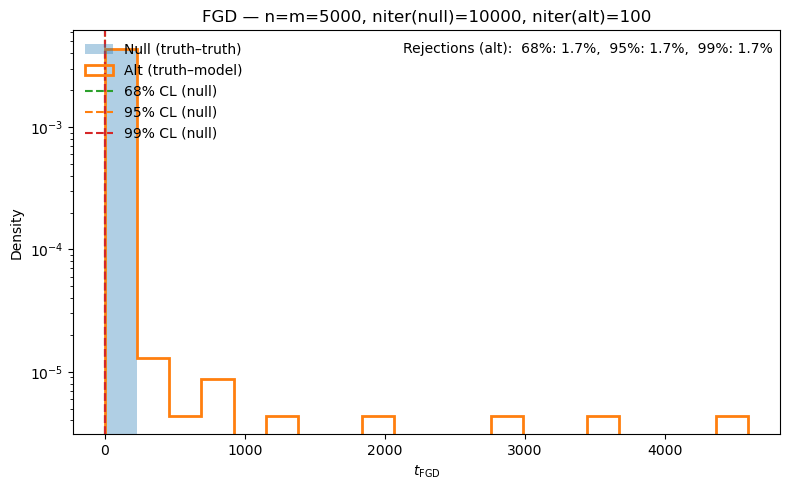

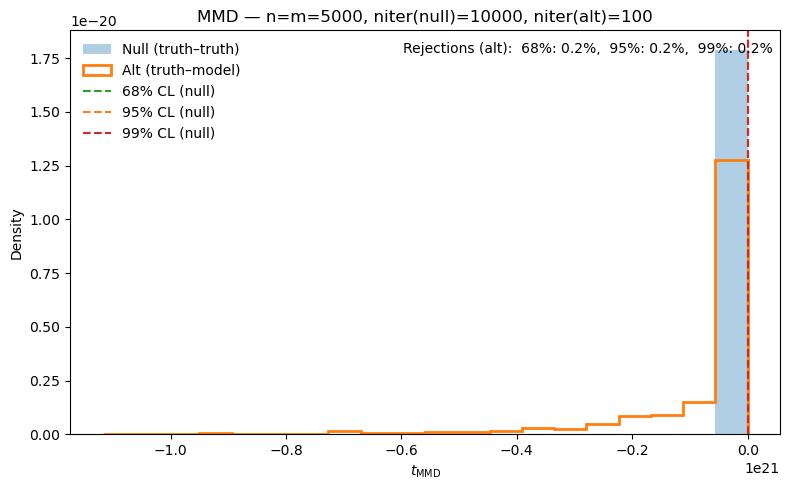

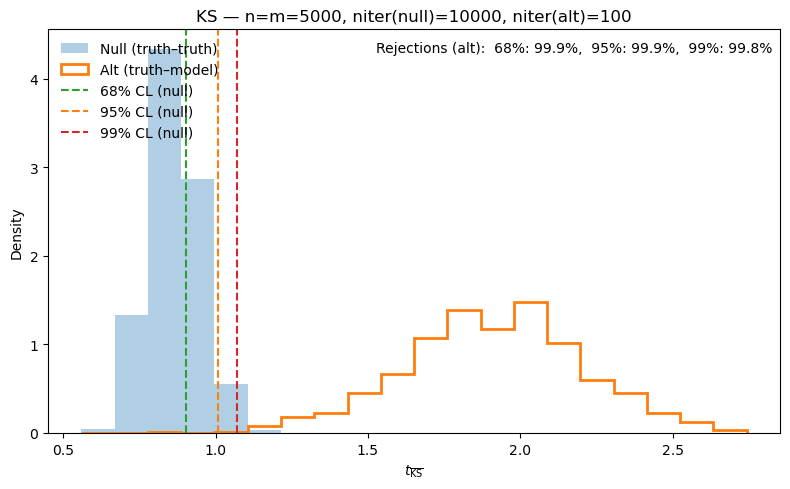

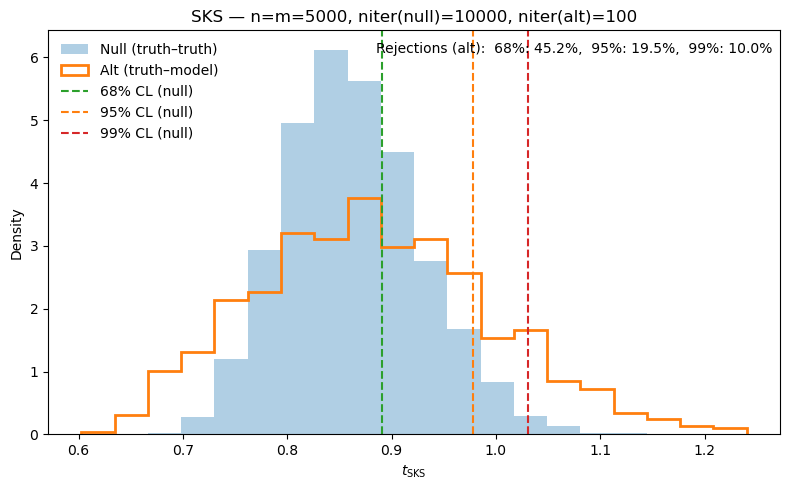

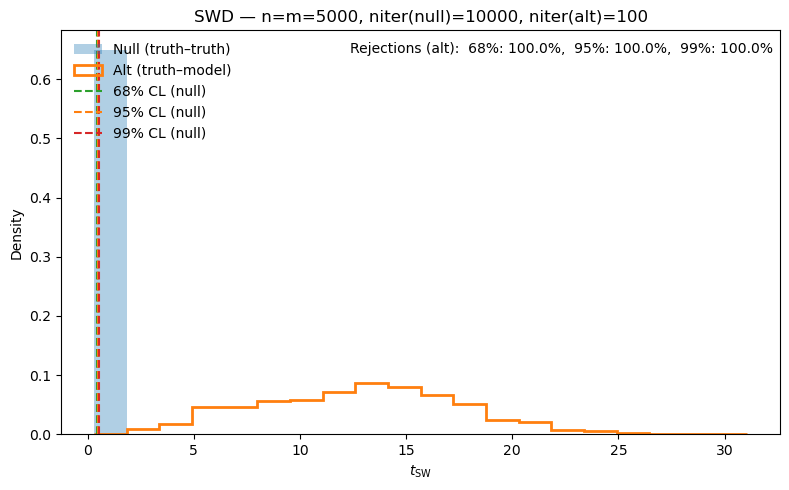

In [ ]:
# 1) Build the alternative (observed) distribution
observed = compute_observed_distributions(
    metrics_config   = metrics_config,
    unique_key       = unique_key,
    dist_1_num       = dist_1_num,           # truth (float32)
    dist_2_num       = dist_2_num,           # model (float32)
    ndims            = ndims,
    batch_size_test  = batch_size_test,      # 5_000
    niter_obs        = 1000,                  # as requested
    dtype            = tf.float64,
    use_tf           = True,
    verbose          = False
)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
plot_null_vs_alt(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/")
)
